## Prediction of speaker dataset

In [2]:
from preprocessing_class import Preprocessing, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score, precision_score, recall_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords 
import numpy as np
import string, gc
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [3]:
# load dataset
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)

In [4]:
alllabs = np.where(alllabs == 1, 0, 1)

In [5]:
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(57413, 57413, array([0, 1]))

### Split of the dataset

In [6]:
# train test split here for test in final prediction

X_train, X_test, y_train, y_test = train_test_split(
    alltxt, alllabs, 
    test_size=0.20, 
    stratify=alllabs, 
    random_state=42
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.20, 
    stratify=y_train, 
    random_state=42
)

In [7]:
len(X_train_sub), len(y_train_sub), len(X_val), len(y_val), len(X_train), len(y_train), len(X_test), len(y_test)

(36744, 36744, 9186, 9186, 45930, 45930, 11483, 11483)

## Experiment 1

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- CountVectorizer

Model:
- Logistic Regression

In [8]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [9]:
# vectorization  
#TODO limit to X vocabulary

final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=2, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

In [10]:
# building vectorizer on the train set

vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=10000, preprocessor=prep)

# train on the sub train
vectorised_train_sub = vectoriser.fit_transform(X_train_sub)
vectorised_val = vectoriser.transform(X_val)

### Running models

#### On simple split

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter) 

def pipeline(model, X_train, y_train, X_test, y_test):
    # fit and preidct Xtrain, Xtest 
    model.fit(X_train,y_train)

    # preds
    y_pred_train = model.predict(X_train)
    ypred_train_prob = model.predict_proba(X_train) # probas for ROC

    y_pred = model.predict(X_test)
    ypred_prob = model.predict_proba(X_test)

    print(f1_score(y_train,y_pred_train, average="macro"),f1_score(y_test,y_pred, average="macro"))
    print(average_precision_score(y_train,y_pred_train), average_precision_score(y_test,y_pred,))
    # print(roc_auc_score(y_train, ypred_train_prob), f1_score(y_test,ypred_prob))

    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train)
    plt.show()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()

    return model

0.8268475068670851 0.7098464153103593
0.935435322992903 0.909718883673154


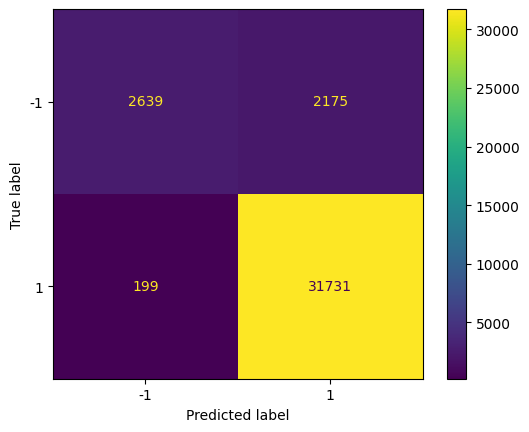

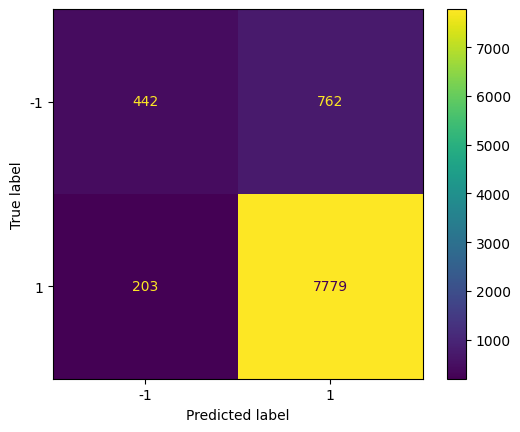

In [18]:
lr = build_model(name="logreg")
lr = pipeline(lr, vectorised_train_sub, y_train_sub, vectorised_val, y_val)

#### Cross validation, then test

In [9]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# Plot CV train vs validation metrics across folds + test as reference line

def plot(train_cv_metrics, val_cv_metrics, test_metrics):

    metric_names = ["AUC", "F1", "Average Precision", "Recall", "Precision"]
    folds = np.arange(1, len(val_cv_metrics["AUC"]) + 1)

    fig, axes = plt.subplots(1, len(metric_names), figsize=(24, 4), sharex=True)

    for ax, metric_name in zip(axes, metric_names):
        train_vals = train_cv_metrics[metric_name]
        val_vals = val_cv_metrics[metric_name]
        test_val = test_metrics[metric_name]

        ax.plot(folds, train_vals, marker="o", label="Train CV")
        ax.plot(folds, val_vals, marker="o", label="Validation CV")
        ax.axhline(test_val, linestyle="--", linewidth=2, label="Test")

        ax.set_title(metric_name)
        ax.set_xlabel("Fold")
        ax.set_xticks(folds)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Score")
    handles, labels = axes[-1].get_legend_handles_labels()
    plt.suptitle("Cross-validation metrics (Train vs Validation) with Test reference", y=1.12)
    plt.tight_layout()
    plt.legend()
    plt.show()

def cv_train(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test, cv=5, test_size=0.2):
    # split in train val, do a cross validation, then evaluate on the final test set
    # takes in untrained model

    train_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    val_cv_metrics = {
        "AUC": [],
        "F1": [],
        "Average Precision": [],
        "Recall": [],
        "Precision": [],
    }

    # splits
    cv_splits = StratifiedKFold(cv, shuffle=True, random_state=0)
    for i, (train_idx, test_idx) in enumerate(cv_splits.split(X_train, y_train)):
        print("Fold ", i)
        X_train_sub, y_train_sub, X_val, y_val = X_train[train_idx], y_train[train_idx], X_train[test_idx], y_train[test_idx]

        # vectorising
        vectoriser = build_vectorizer(**vect_kwargs)

        # train on the sub train
        vect_train_sub = vectoriser.fit_transform(X_train_sub)
        vect_val = vectoriser.transform(X_val)

        clf = model(**kwargs)
        clf.fit(vect_train_sub, y_train_sub)

        # predictions
        y_pred_train = clf.predict(vect_train_sub)
        ypred_train_prob = clf.predict_proba(vect_train_sub)[:, 1]  # probas for ROC

        y_pred = clf.predict(vect_val)
        ypred_prob = clf.predict_proba(vect_val)[:, 1]

        # evaluation
        f1_train, f1_val = f1_score(y_train_sub, y_pred_train, average="macro"), f1_score(y_val, y_pred, average="macro")
        ap_train, ap_val = average_precision_score(y_train_sub, y_pred_train), average_precision_score(y_val, y_pred)
        auc_train, auc_val = roc_auc_score(y_train_sub, ypred_train_prob), roc_auc_score(y_val, ypred_prob)
        prec_train, prec_val = precision_score(y_train_sub, y_pred_train, average="macro"), precision_score(y_val, y_pred, average="macro")
        rec_train, rec_val = recall_score(y_train_sub, y_pred_train, average="macro"), recall_score(y_val, y_pred, average="macro")

        train_cv_metrics["AUC"].append(auc_train)
        train_cv_metrics["F1"].append(f1_train)
        train_cv_metrics["Average Precision"].append(ap_train)
        train_cv_metrics["Recall"].append(rec_train)
        train_cv_metrics["Precision"].append(prec_train)

        val_cv_metrics["AUC"].append(auc_val)
        val_cv_metrics["F1"].append(f1_val)
        val_cv_metrics["Average Precision"].append(ap_val)
        val_cv_metrics["Recall"].append(rec_val)
        val_cv_metrics["Precision"].append(prec_val)

    # final test evaluation
    vectoriser = build_vectorizer(**vect_kwargs)

    vect_train = vectoriser.fit_transform(X_train)
    vect_test = vectoriser.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

    plot(train_cv_metrics, val_cv_metrics, test_metrics)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.9658657841701728
F1: 0.8387528801743145
Average Precision: 0.9386662995637381
Recall: 0.783211425055361
Precision: 0.9402460276946998

Final Test Results:
AUC: 0.8594385055760546
F1: 0.7133375320287809
Average Precision: 0.9101286465061125
Recall: 0.6724776901209238
Precision: 0.8084186817465733


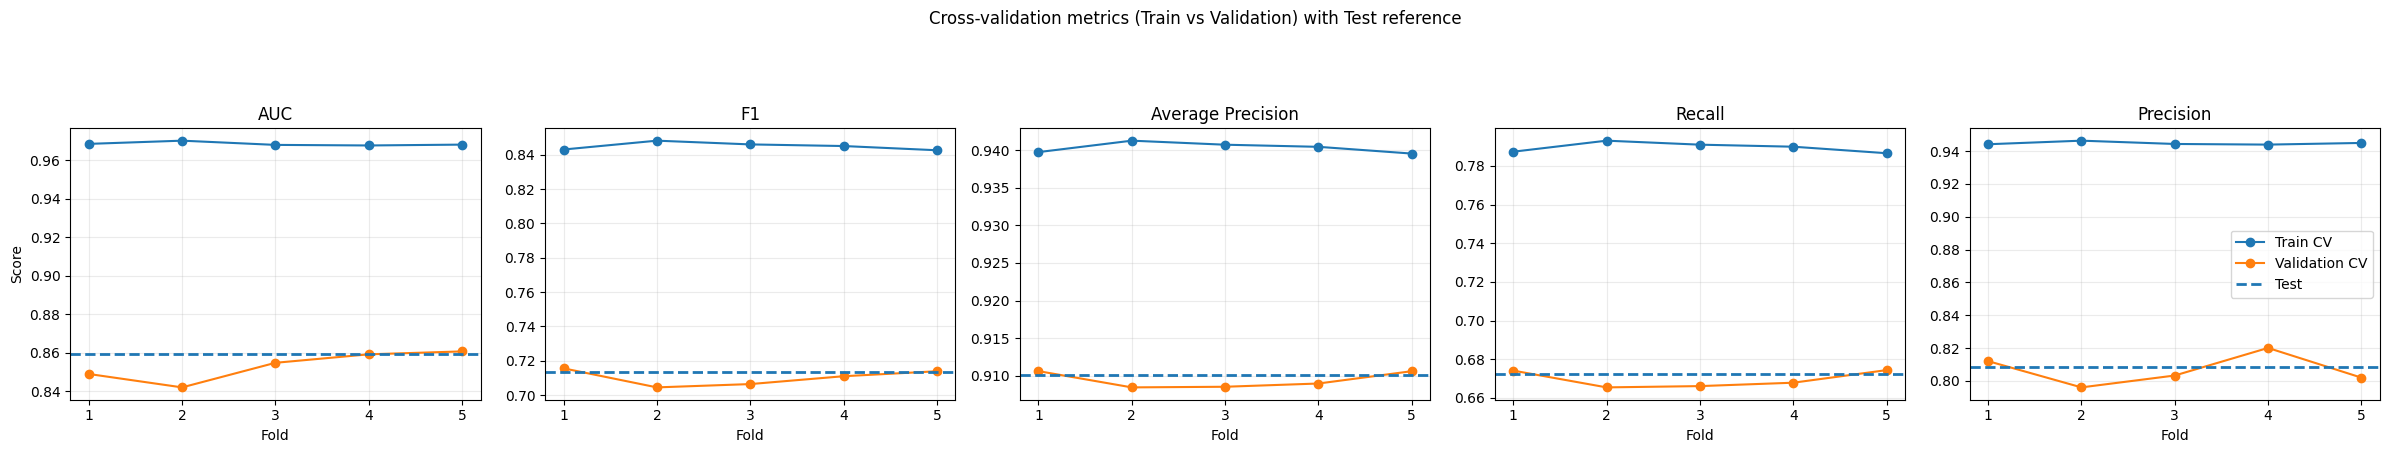

In [27]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.9665533469911639
F1: 0.9669457696426833
Average Precision: 0.9397952581132064
Recall: 0.9953397474443776
Precision: 0.9401268458917077

Final Test Results:
AUC: 0.8615212936899718
F1: 0.9425331912006978
Average Precision: 0.9112854847873982
Recall: 0.9747444377630787
Precision: 0.9123827392120075


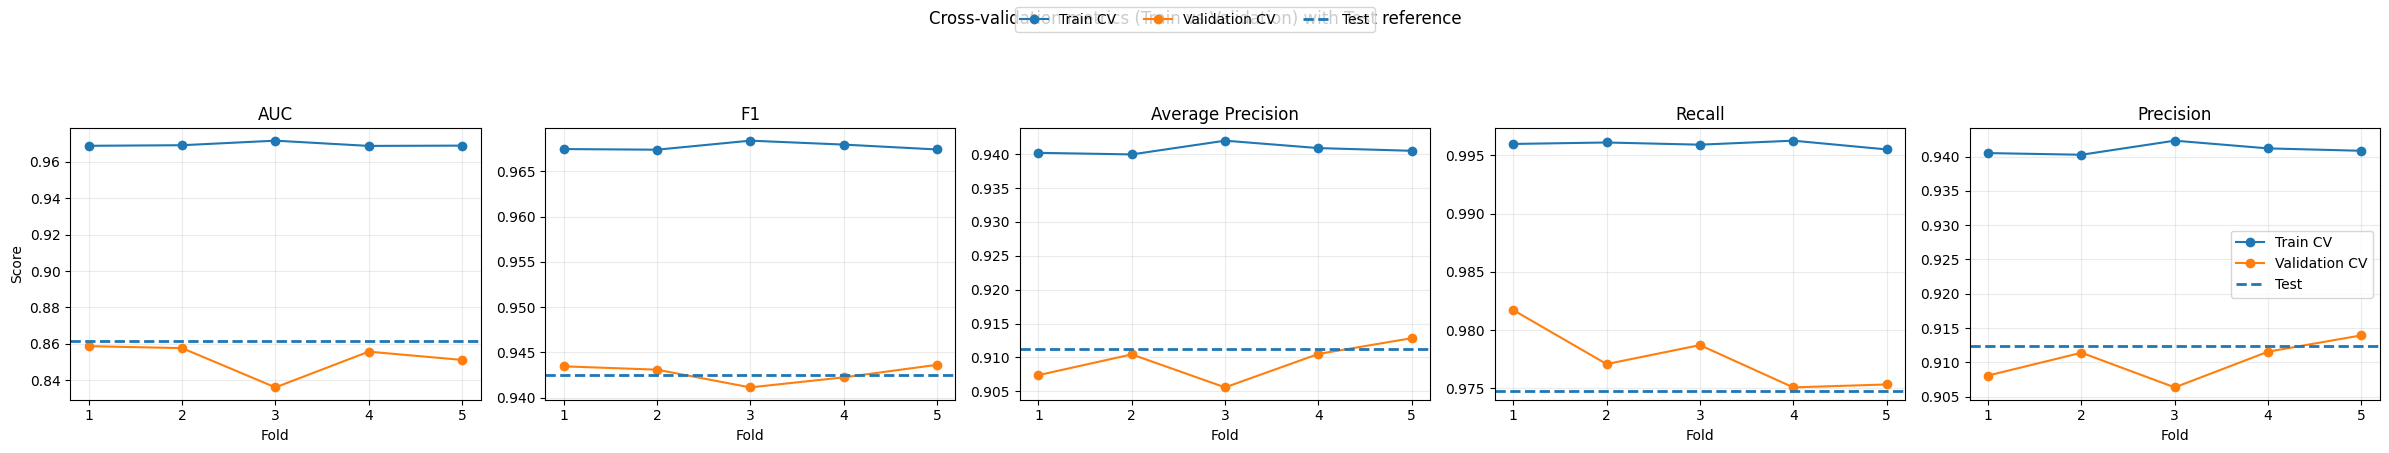

In [77]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

#### Model on final train and test 

In [10]:
def eval_test(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test):
    # vectorising
    vectorizer = build_vectorizer(**vect_kwargs)
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    clf = model(**kwargs)
    clf.fit(vect_train, y_train)

    y_pred_train = clf.predict(vect_train)
    ypred_train_prob = clf.predict_proba(vect_train)[:, 1]  # probas for ROC

    y_pred = clf.predict(vect_test)
    ypred_prob = clf.predict_proba(vect_test)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [29]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.9658657841701728
F1: 0.8387528801743145
Average Precision: 0.9386662995637381
Recall: 0.783211425055361
Precision: 0.9402460276946998

Final Test Results:
AUC: 0.8594385055760546
F1: 0.7133375320287809
Average Precision: 0.9101286465061125
Recall: 0.6724776901209238
Precision: 0.8084186817465733


In [80]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"count", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.9665533469911639
F1: 0.9669457696426833
Average Precision: 0.9397952581132064
Recall: 0.9953397474443776
Precision: 0.9401268458917077

Final Test Results:
AUC: 0.8615212936899718
F1: 0.9425331912006978
Average Precision: 0.9112854847873982
Recall: 0.9747444377630787
Precision: 0.9123827392120075


## Experiment 2

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french.

Vectorizer:
- TfidfVectorizer

Model:
- Logistic Regression

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.9217451165911632
F1: 0.6879634289209238
Average Precision: 0.9018788511249369
Recall: 0.6391970485616711
Precision: 0.8933196497638656

Final Test Results:
AUC: 0.8534185174160561
F1: 0.6459897322954572
Average Precision: 0.8943793056165267
Recall: 0.6084969990457412
Precision: 0.8435745395669405


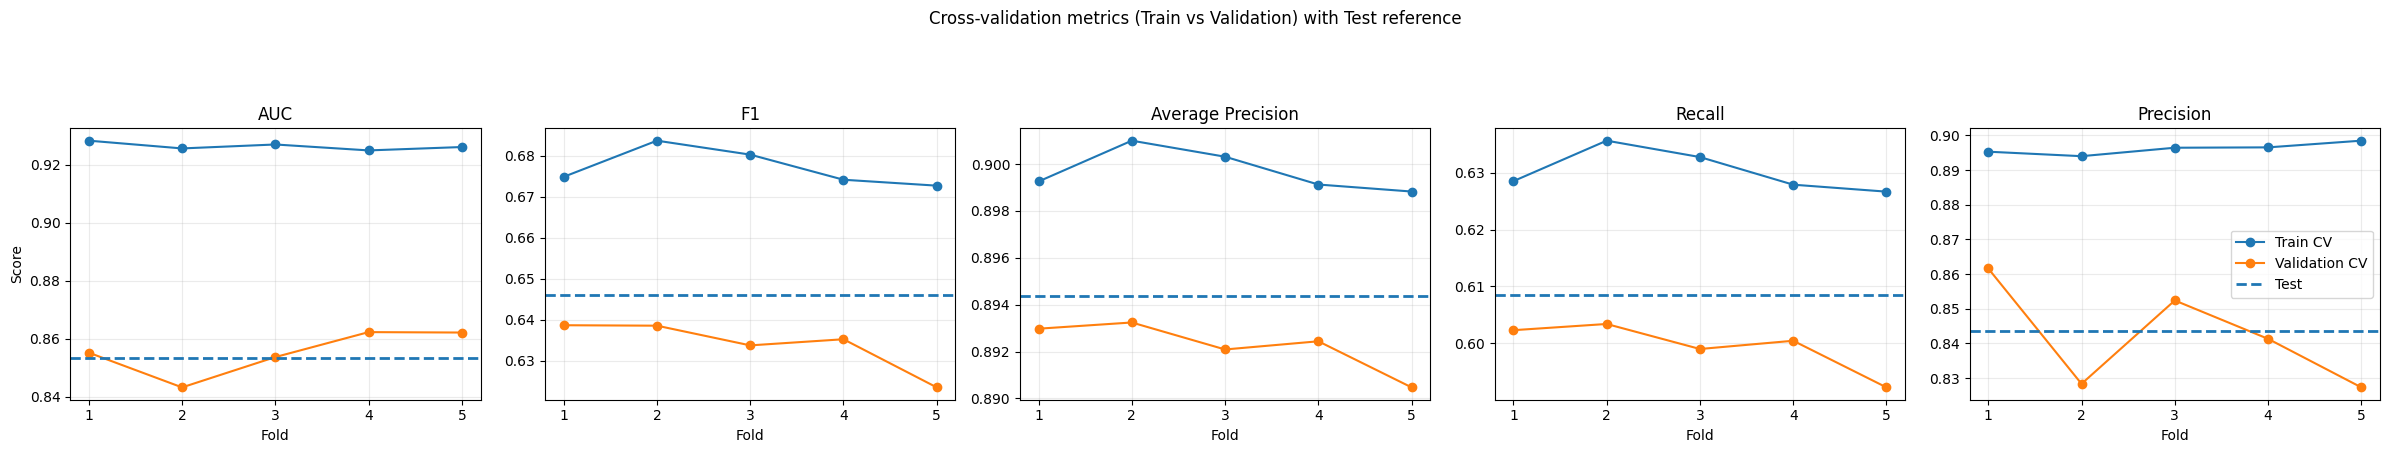

In [30]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":10000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.9240885531419373
F1: 0.9463847235797554
Average Precision: 0.9024162425053778
Recall: 0.9946382040489076
Precision: 0.902596516756855

Final Test Results:
AUC: 0.8634534181178659
F1: 0.9400855920114123
Average Precision: 0.8941708440680796
Recall: 0.9906794948887553
Precision: 0.8944082519001085


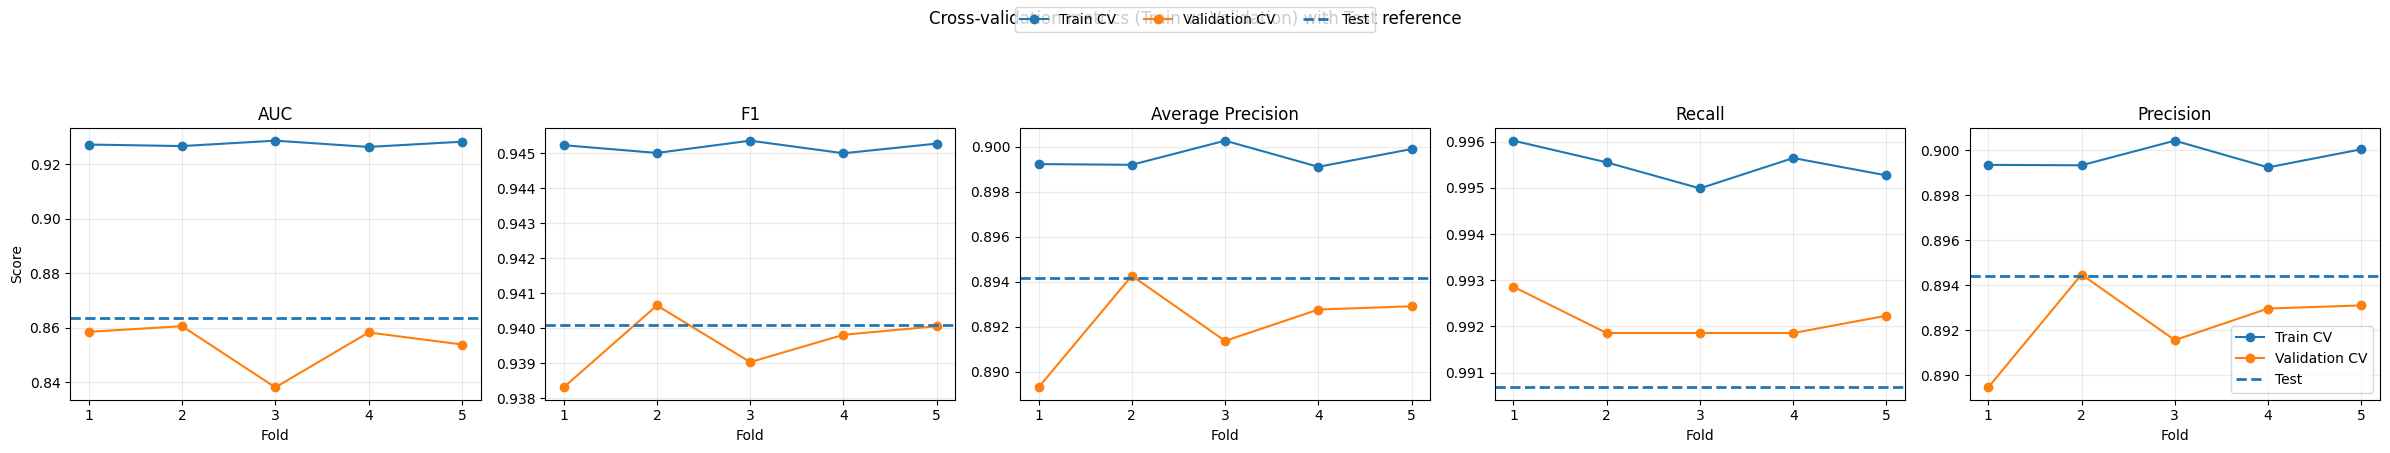

In [81]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":10000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.7314232679458784
F1: 0.9317057154248458
Average Precision: 0.8756686900695206
Recall: 0.9953648025656444
Precision: 0.8756998633337741

Final Test Results:
AUC: 0.7253776247944814
F1: 0.9317254000281545
Average Precision: 0.8759902419296897
Recall: 0.9949889757466426
Precision: 0.8760257654636902


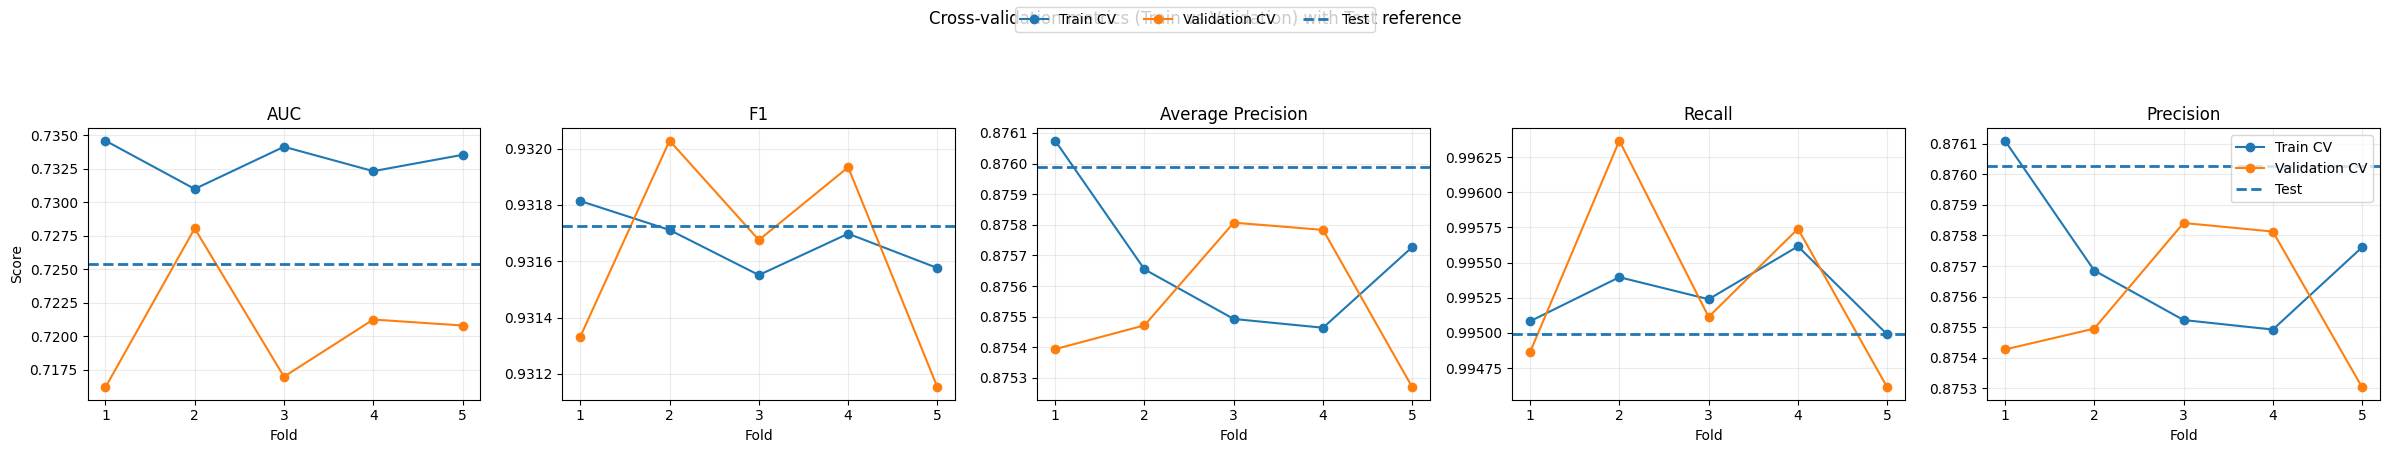

In [ ]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":10000, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

In [25]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.7314232679458784
F1: 0.9317057154248458
Average Precision: 0.8756686900695206
Recall: 0.9953648025656444
Precision: 0.8756998633337741

Final Test Results:
AUC: 0.7253776247944814
F1: 0.9317254000281545
Average Precision: 0.8759902419296897
Recall: 0.9949889757466426
Precision: 0.8760257654636902


In [31]:
# with scaling !!
from sklearn import preprocessing

def eval_test(model, kwargs, vect_kwargs, X_train, y_train, X_test, y_test):
    # vectorising
    vectorizer = build_vectorizer(**vect_kwargs)
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(vect_train) # avoid dense matrix
    X_train_scaled = scaler.transform(vect_train)
    X_test_scaled = scaler.transform(vect_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average="macro"), f1_score(y_test, y_pred, average="macro")
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average="macro"), precision_score(y_test, y_pred, average="macro")
    rec_train, rec_test = recall_score(y_train, y_pred_train, average="macro"), recall_score(y_test, y_pred, average="macro")

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [32]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.9979645378523347
F1: 0.9777332247067368
Average Precision: 0.9919470318234642
Recall: 0.9728461688496347
Precision: 0.9827665018009986

Final Test Results:
AUC: 0.7507150948032515
F1: 0.6585600309063996
Average Precision: 0.909914781332079
Recall: 0.6708610105021746
Precision: 0.6491748930462131


In [29]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":final_stopwords_list, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.7322972828357981
F1: 0.9317698980011033
Average Precision: 0.87645187554095
Recall: 0.9944878733213068
Precision: 0.876493320083913

Final Test Results:
AUC: 0.726290663379701
F1: 0.9317242674680691
Average Precision: 0.876524702201707
Recall: 0.9942874323511726
Precision: 0.8765682982859162


## Experiment 3

Preprocessing:
- lower case
- remove punctuation
- stemming 
- keep all capital words and accents
- language french
- remove numbers

Vectorizer:
- Tfidf

Model:
- Logistic Regression

In [7]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "stem", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [19]:
from nltk.stem import SnowballStemmer 
stemmer = SnowballStemmer("french")
stemmed_stopwords = [stemmer.stem(word) for word in final_stopwords_list]

Fold  0
Fold  1
Fold  2
Fold  3
Fold  4
Final Train Results:
AUC: 0.7583983325962516
F1: 0.9328802238893723
Average Precision: 0.8788884682090623
Recall: 0.9938614952896372
Precision: 0.8789497008641701

Final Test Results:
AUC: 0.7542736878275061
F1: 0.9316717611098049
Average Precision: 0.8775839989240133
Recall: 0.9927841250751653
Precision: 0.8776468503588198


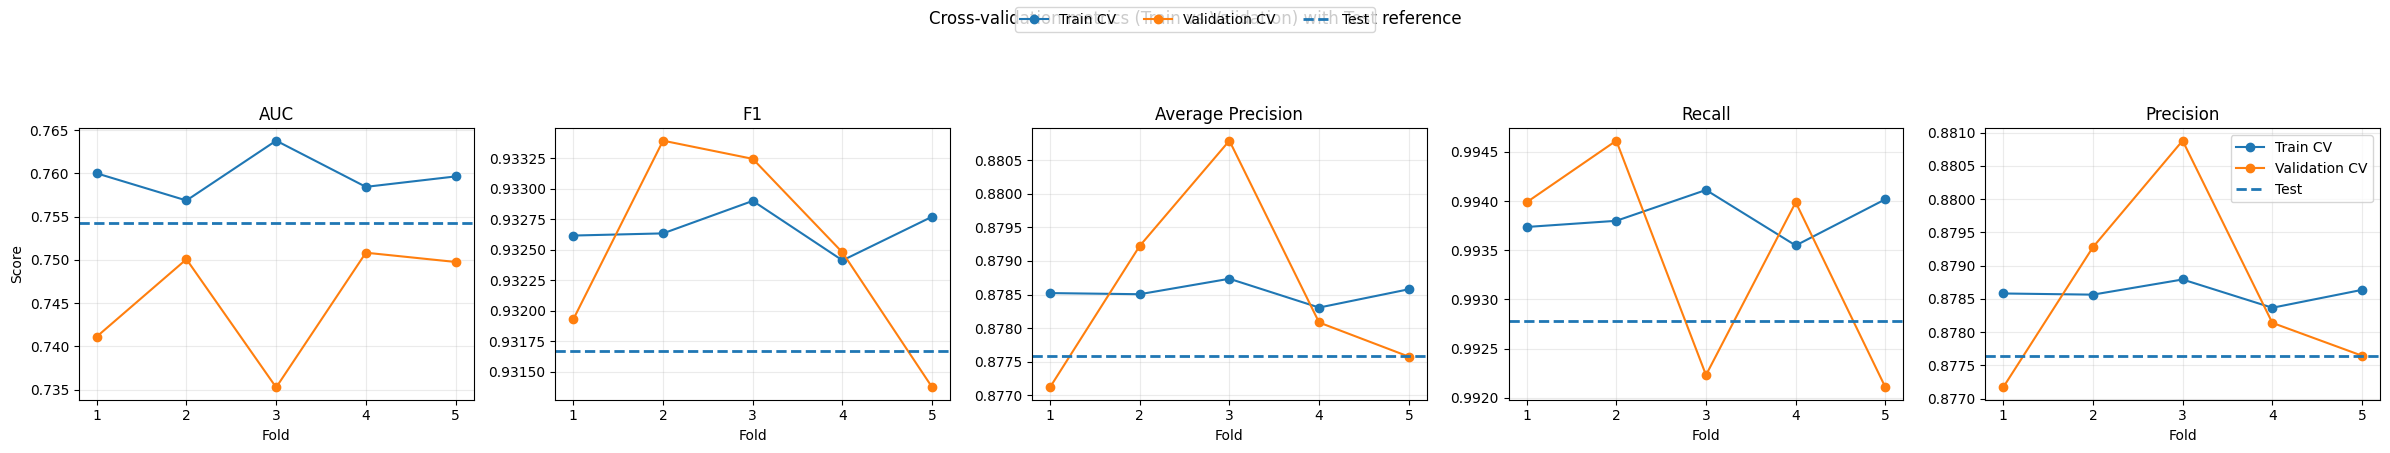

In [20]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"tfidf", "stop_words":stemmed_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

In [21]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":stemmed_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

Final Train Results:
AUC: 0.7583983325962516
F1: 0.9328802238893723
Average Precision: 0.8788884682090623
Recall: 0.9938614952896372
Precision: 0.8789497008641701

Final Test Results:
AUC: 0.7542736878275061
F1: 0.9316717611098049
Average Precision: 0.8775839989240133
Recall: 0.9927841250751653
Precision: 0.8776468503588198


## Experiment 4
with lemma

In [27]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = "lemma", # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [25]:
import spacy
NLP_FR = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

lemma_stopwords = []

for word in final_stopwords_list:
    doc = NLP_FR(word)
    for token in doc:
        lemma_stopwords.append(token.lemma_.lower())

Fold  0


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  1


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  2


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  3


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Fold  4


/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(
/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Final Train Results:
AUC: 0.7519164940369645
F1: 0.9325631191322149
Average Precision: 0.8789829097834209
Recall: 0.9930096211665664
Precision: 0.8790533646808322

Final Test Results:
AUC: 0.7490304916663837
F1: 0.9316191014410851
Average Precision: 0.8786459419084509
Recall: 0.9912808177991581
Precision: 0.878731343283582


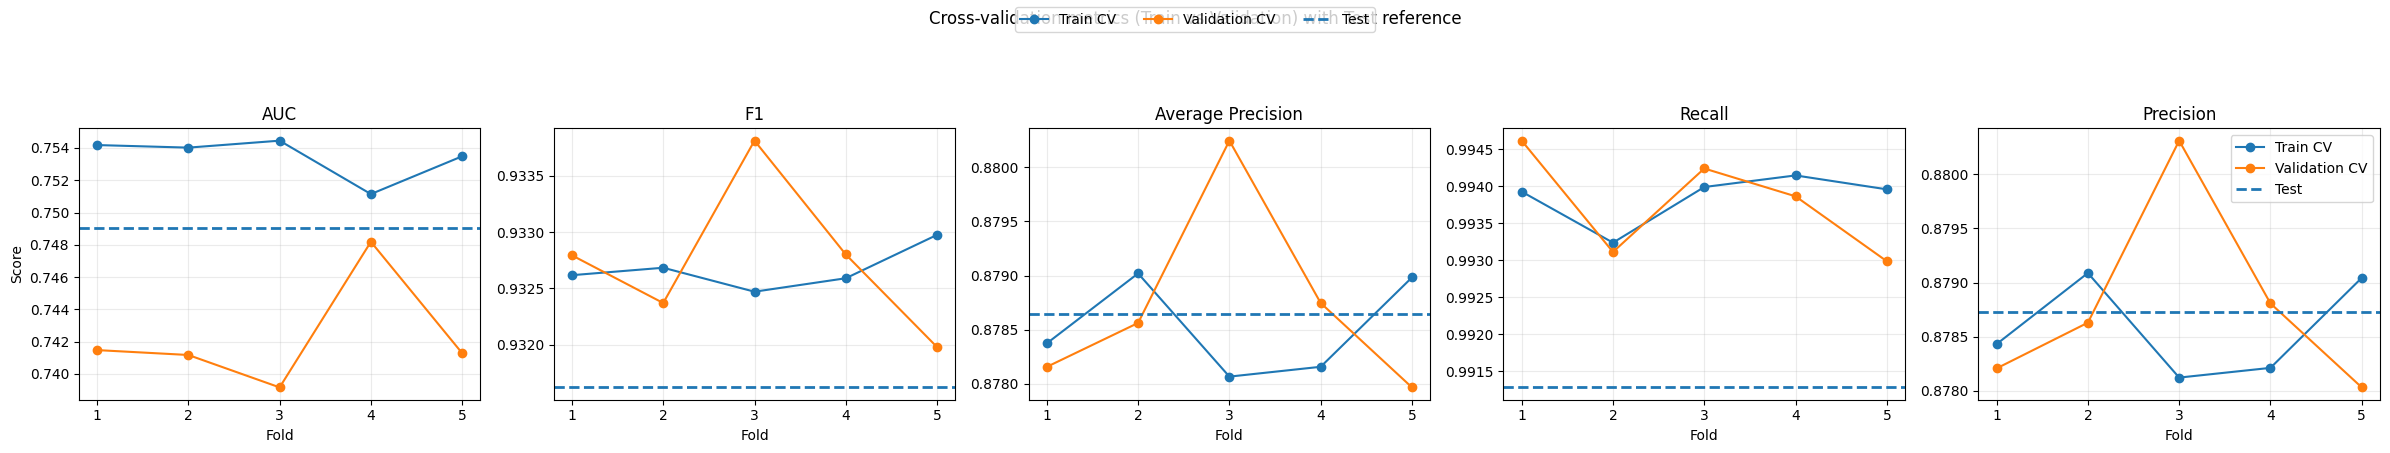

In [28]:
cv_train(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000}, 
    {"name":"tfidf", "stop_words":lemma_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,
    cv=5,
    test_size=0.2)

In [30]:
eval_test(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    {"name":"tfidf", "stop_words":lemma_stopwords, "max_features":None, "preprocessor":prep},
    X_train,
    y_train,
    X_test,
    y_test,)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['luir'] not in stop_words.
  warnings.warn(


Final Train Results:
AUC: 0.7519164940369645
F1: 0.9325631191322149
Average Precision: 0.8789829097834209
Recall: 0.9930096211665664
Precision: 0.8790533646808322

Final Test Results:
AUC: 0.7490304916663837
F1: 0.9316191014410851
Average Precision: 0.8786459419084509
Recall: 0.9912808177991581
Precision: 0.878731343283582


## Experiment 5

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french
- remove numbers

Vectorizer:
- Embeddings (word2vec)

Model:
- Logistic Regression

In [30]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [44]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# preprocess train before word2vec
prep_X_train = [prep.process(txt) for txt in X_train]

text = [t.split() for t in prep_X_train] # p is the class

# the following configuration is the default configuration
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)
# sauvegarder modèle !!!!!
w2v.save("W2v-pres-exp5.dat")
# pour load
# w2v = gensim.models.Word2Vec.load("W2v-pres-exp5.dat")

def embed(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)


2026-03-14 15:11:33,382 : INFO : collecting all words and their counts
2026-03-14 15:11:33,383 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-14 15:11:33,464 : INFO : PROGRESS: at sentence #10000, processed 212951 words, keeping 15560 word types
2026-03-14 15:11:33,547 : INFO : PROGRESS: at sentence #20000, processed 427360 words, keeping 21160 word types
2026-03-14 15:11:33,634 : INFO : PROGRESS: at sentence #30000, processed 642222 words, keeping 25090 word types
2026-03-14 15:11:33,720 : INFO : PROGRESS: at sentence #40000, processed 857679 words, keeping 28172 word types
2026-03-14 15:11:33,766 : INFO : collected 29748 word types from a corpus of 985157 raw words and 45930 sentences
2026-03-14 15:11:33,767 : INFO : Creating a fresh vocabulary
2026-03-14 15:11:33,843 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 10252 unique words (34.46% of original 29748, drops 19496)', 'datetime': '2026-03-14T15:11:33.843314', 'gensim

In [45]:
prep_X_test = [prep.process(txt) for txt in X_test]

prep_X_train_vect = [embed(text, w2v) for text in prep_X_train]
prep_X_test_vect = [embed(text, w2v) for text in prep_X_test]

In [42]:
from sklearn import preprocessing

def eval_test_vect(model, kwargs, X_train, y_train, X_test, y_test):
    # pass the vectorized train and tes    
    # scaling
    scaler = preprocessing.StandardScaler(with_mean=False).fit(X_train) # avoid dense matrix
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = model(**kwargs)
    clf.fit(X_train_scaled, y_train)

    y_pred_train = clf.predict(X_train_scaled)
    ypred_train_prob = clf.predict_proba(X_train_scaled)[:, 1]  # probas for ROC

    y_pred = clf.predict(X_test_scaled)
    ypred_prob = clf.predict_proba(X_test_scaled)[:, 1]

    f1_train, f1_test = f1_score(y_train, y_pred_train, average='macro'), f1_score(y_test, y_pred, average='macro')
    ap_train, ap_test = average_precision_score(y_train, y_pred_train), average_precision_score(y_test, y_pred)
    auc_train, auc_test = roc_auc_score(y_train, ypred_train_prob), roc_auc_score(y_test, ypred_prob)
    prec_train, prec_test = precision_score(y_train, y_pred_train, average='macro'), precision_score(y_test, y_pred, average='macro')
    rec_train, rec_test = recall_score(y_train, y_pred_train, average='macro'), recall_score(y_test, y_pred, average='macro')

    final_train_metrics = {
        "AUC": auc_train,
        "F1": f1_train,
        "Average Precision": ap_train,
        "Recall": rec_train,
        "Precision": prec_train,
    }

    test_metrics = {
        "AUC": auc_test,
        "F1": f1_test,
        "Average Precision": ap_test,
        "Recall": rec_test,
        "Precision": prec_test,
    }

    # print summary
    print("Final Train Results:")
    for metric_name, metric_value in final_train_metrics.items():
        print(f"{metric_name}: {metric_value}")

    print("\nFinal Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name}: {metric_value}")

In [48]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    prep_X_train_vect,
    y_train,    
    prep_X_test_vect,
    y_test
)

Final Train Results:
AUC: 0.5996053148098965
F1: 0.9298783687653789
Average Precision: 0.8697607088299805
Recall: 0.9989226297855281
Precision: 0.8697615567529833

Final Test Results:
AUC: 0.5862969629530482
F1: 0.9304972478776006
Average Precision: 0.8703310289427719
Recall: 0.9995991180597315
Precision: 0.8703315881326352


## Experiment 6

Preprocessing:
- lower case
- remove punctuation
- no stemming or lemmatization
- keep all capital words and accents
- language french
- remove numbers

Vectorizer:
- Embeddings using embedders

Model:
- Logistic Regression

In [ ]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True
)

# Encode with the task specified
X_train_emb = model.encode(X_train, batch_size=32, show_progress_bar=True, task="classification")
X_test_emb = model.encode(X_test, batch_size=32, show_progress_bar=True, task="classification")

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 29511.37it/s]
Default prompt name is set to 'document'. This prompt will be applied to all `encode()` calls, except if `encode()` is called with `prompt` or `prompt_name` parameters.
Batches:   0%|          | 0/1436 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Batches: 100%|██████████| 359/359 [01:34<00:00,  3.80it/s]


In [57]:
eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    X_train_emb,
    y_train,    
    X_test_emb,
    y_test
)

Final Train Results:
AUC: 0.8659724208146591
F1: 0.942427717752158
Average Precision: 0.9084828924810417
Recall: 0.9779765484064943
Precision: 0.9093725974419309

Final Test Results:
AUC: 0.8475847529015662
F1: 0.9373641763654803
Average Precision: 0.9035831418743665
Recall: 0.9726398075766687
Precision: 0.9045577407027682


## Experiment 7 with HMM (todo)


In [ ]:
prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = 'stem', # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
)

In [57]:
# hmm work with count only

vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=2000, preprocessor=prep)

In [58]:
vect_Xtrain = vectoriser.fit_transform(X_train)
vect_Xtest = vectoriser.transform(X_test)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aur', 'aurion', 'auron', 'avi', 'avion', 'avon', 'ayon', 'dan', 'euss', 'eussion', 'eûm', 'fuss', 'fussion', 'fûm', 'mêm', 'notr', 'ser', 'serion', 'seron', 'somm', 'soyon', 'votr', 'éti', 'étion', 'ête'] not in stop_words.
  warnings.warn(


In [27]:
len(vectoriser.vocabulary_)

2000

In [28]:
idx_1 = np.where(y_train == 1)[0]
idx_m1 = np.where(y_train == -1)[0]

In [59]:
from hmmlearn import hmm

# Train Model A classe 1 
model_a = hmm.MultinomialHMM(n_components=3) 
model_a.fit(vect_Xtrain[idx_1].toarray())

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


,n_components,3
,n_trials,"array([ 2, 9...hape=(39912,))"
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,RandomState(M...0x7F514A5C7040
,n_iter,10
,tol,0.01
,verbose,False
,params,'ste'
,init_params,'ste'


In [60]:
# Train Model B
model_b = hmm.MultinomialHMM(n_components=3)
model_b.fit(vect_Xtrain[idx_m1].toarray())

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


,n_components,3
,n_trials,"array([11, 11...shape=(6018,))"
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,RandomState(M...0x7F514A5C7040
,n_iter,10
,tol,0.01
,verbose,False
,params,'ste'
,init_params,'ste'


In [61]:
pred = []

for el in vect_Xtest:
    score_1 = model_a.score(el.toarray())
    score_m1 = model_b.score(el.toarray())

    logL = np.array([score_1, score_m1])
    probs = np.exp(logL - np.max(logL))  # subtract max for numerical stability
    probs /= probs.sum()
    pred.append(probs)

pred = np.array(pred)

In [62]:
pred_train = []

for el in vect_Xtrain:
    score_1 = model_a.score(el.toarray())
    score_m1 = model_b.score(el.toarray())

    logL = np.array([score_1, score_m1])
    probs = np.exp(logL - np.max(logL))  # subtract max for numerical stability
    probs /= probs.sum()
    pred_train.append(probs)

pred_train = np.array(pred_train)

In [63]:
predictions_train = np.where(pred_train[:, 0] > pred_train[:, 1], 1, -1)
predictions = np.where(pred[:, 0] > pred[:, 1], 1, -1)

In [64]:
f1_train, f1_test = f1_score(y_train, predictions_train), f1_score(y_test, predictions)
ap_train, ap_test = average_precision_score(y_train, predictions_train), average_precision_score(y_test, predictions)
auc_train, auc_test = roc_auc_score(y_train, pred_train[:,0]), roc_auc_score(y_test, pred[:, 0])
prec_train, prec_test = precision_score(y_train, predictions_train), precision_score(y_test, predictions)
rec_train, rec_test = recall_score(y_train, predictions_train), recall_score(y_test, predictions)

In [65]:
print(f1_train, f1_test)
print(ap_train, ap_test)
print(auc_train, auc_test)
print(prec_train, prec_test)
print(rec_train, rec_test)

0.8198420813451488 0.8137758011175733
0.9248753794007117 0.9225594271768502
0.7995499120997401 0.7780258096050514
0.9462693417256753 0.9439153439153439
0.7232160753658048 0.7151733814391662


## Baseline

Prediction of class majority

In [16]:
f1_train, f1_test = f1_score(y_train, np.ones(len(y_train)), average='macro'), f1_score(y_test, np.ones(len(y_test)), average='macro')
ap_train, ap_test = average_precision_score(y_train, np.ones(len(y_train))), average_precision_score(y_test, np.ones(len(y_test)))
auc_train, auc_test = roc_auc_score(y_train, np.ones(len(y_train))), roc_auc_score(y_test, np.ones(len(y_test)))
prec_train, prec_test = precision_score(y_train, np.ones(len(y_train)), average="macro", zero_division=0), precision_score(y_test, np.ones(len(y_test)), average="macro", zero_division=0)
rec_train, rec_test = recall_score(y_train, np.ones(len(y_train)), average="macro", zero_division=0), recall_score(y_test, np.ones(len(y_test)), average="macro", zero_division=0)

print(auc_train, auc_test)
print(f1_train, f1_test)
print(ap_train, ap_test)
print(rec_train, rec_test)
print(prec_train, prec_test)

0.5 0.5
0.11584661584661585 0.11587619340930089
0.1310254735467015 0.13106331098145085
0.5 0.5
0.06551273677335075 0.06553165549072543


Random predictions

In [17]:
np.random.seed(0)
n_runs = 30

f1_train_scores, f1_test_scores = [], []
ap_train_scores, ap_test_scores = [], []
auc_train_scores, auc_test_scores = [], []
prec_train_scores, prec_test_scores = [], []
rec_train_scores, rec_test_scores = [], []

for _ in range(n_runs):
    a = np.random.choice([-1, 1], size=len(y_train))
    b = np.random.choice([-1, 1], size=len(y_test))

    f1_train_scores.append(f1_score(y_train, a, average='macro'))
    f1_test_scores.append(f1_score(y_test, b, average='macro'))

    ap_train_scores.append(average_precision_score(y_train, a))
    ap_test_scores.append(average_precision_score(y_test, b))

    auc_train_scores.append(roc_auc_score(y_train, np.where(a == 1, 1, 0)))
    auc_test_scores.append(roc_auc_score(y_test, np.where(b == 1, 1, 0)))

    prec_train_scores.append(precision_score(y_train, a, average="macro", zero_division=0))
    prec_test_scores.append(precision_score(y_test, b, average="macro", zero_division=0))

    rec_train_scores.append(recall_score(y_train, a, average="macro", zero_division=0))
    rec_test_scores.append(recall_score(y_test, b, average="macro", zero_division=0))

print("Mean over 30 random runs:")
print("AUC:", np.mean(auc_train_scores), np.mean(auc_test_scores))
print("F1:", np.mean(f1_train_scores), np.mean(f1_test_scores))
print("AP:", np.mean(ap_train_scores), np.mean(ap_test_scores))
print("Recall:", np.mean(rec_train_scores), np.mean(rec_test_scores))
print("Precision:", np.mean(prec_train_scores), np.mean(prec_test_scores))

Mean over 30 random runs:
AUC: 0.5001256415659815 0.4981073522324973
F1: 0.06923015050171806 0.06873858288311298
AP: 0.13106414432327934 0.13070349832772735
Recall: 0.16660204571470774 0.1652122554448136
Precision: 0.04369349239425664 0.043398027554645786


In [ ]:
# np.random.seed(0)
# n_runs = 30

# f1_train_scores, f1_test_scores = [], []
# ap_train_scores, ap_test_scores = [], []
# auc_train_scores, auc_test_scores = [], []
# prec_train_scores, prec_test_scores = [], []
# rec_train_scores, rec_test_scores = [], []

# for _ in range(n_runs):
#     a = np.random.choice([-1, 1], size=len(y_train))
#     b = np.random.choice([-1, 1], size=len(y_test))

#     f1_train_scores.append(f1_score(y_train, a,))
#     f1_test_scores.append(f1_score(y_test, b))

#     ap_train_scores.append(average_precision_score(y_train, a))
#     ap_test_scores.append(average_precision_score(y_test, b))

#     auc_train_scores.append(roc_auc_score(y_train, np.where(a == 1, 1, 0)))
#     auc_test_scores.append(roc_auc_score(y_test, np.where(b == 1, 1, 0)))

#     prec_train_scores.append(precision_score(y_train, a))
#     prec_test_scores.append(precision_score(y_test, b))

#     rec_train_scores.append(recall_score(y_train, a))
#     rec_test_scores.append(recall_score(y_test, b))

# print("Mean over 30 random runs:")
# print("AUC:", np.mean(auc_train_scores), np.mean(auc_test_scores))
# print("F1:", np.mean(f1_train_scores), np.mean(f1_test_scores))
# print("AP:", np.mean(ap_train_scores), np.mean(ap_test_scores))
# print("Recall:", np.mean(rec_train_scores), np.mean(rec_test_scores))
# print("Precision:", np.mean(prec_train_scores), np.mean(prec_test_scores))

Mean over 30 random runs:
AUC: 0.4997468762450538 0.5002231132189598
F1: 0.6343424519033013 0.6339475663861408
AP: 0.8689184283175037 0.8689937466473232
Recall: 0.49952144718380437 0.49898443241798623
Precision: 0.8688571755573709 0.8690334142068763


## Experiment 8 

RNN with low preprocessing, and embeddings

In [45]:
# clean cuda
import torch

# Quick summary
print(torch.cuda.memory_summary())

# Or simpler — just the key numbers
print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved()  / 1e9:.2f} GB")

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 4            |        cudaMalloc retries: 4         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |  13248 KiB | 211968 KiB | 211968 KiB |
|       from large pool |      0 B   |      0 KiB |      0 KiB |      0 KiB |
|       from small pool |      0 B   |  13248 KiB | 211968 KiB | 211968 KiB |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |  13248 KiB | 211968 KiB | 211968 KiB |
|       from large pool |      0 B   |      0 KiB |      0 KiB |

In [ ]:
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            print(type(obj), obj.shape, obj.dtype, 
                  f"{obj.element_size() * obj.nelement() / 1e6:.2f} MB")
    except:
        pass

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/torch/__init__.py:1151: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


In [47]:
gc.collect()
torch.cuda.empty_cache()

In [48]:
from sentence_transformers import SentenceTransformer

# Load model (allow custom code)
model = SentenceTransformer(
    "jinaai/jina-embeddings-v5-text-nano",
    trust_remote_code=True,
    device = "cpu" # aya
)

# Encode with the task specified
X_train_emb = model.encode(X_train, batch_size=16, show_progress_bar=True, task="classification", convert_to_numpy=True)
torch.cuda.empty_cache()
X_test_emb = model.encode(X_test, batch_size=16, show_progress_bar=True, task="classification", convert_to_numpy=True)
torch.cuda.empty_cache()

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 36994.96it/s]
Default prompt name is set to 'document'. This prompt will be applied to all `encode()` calls, except if `encode()` is called with `prompt` or `prompt_name` parameters.
Batches:   0%|          | 0/2871 [00:00<?, ?it/s]/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:202: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be r

In [49]:
# Save
np.save("X_train_emb.npy", X_train_emb)
np.save("X_test_emb.npy",  X_test_emb)

# Load next time — skip the encode step entirely
# X_train_emb = np.load("X_train_emb.npy")
# X_test_emb  = np.load("X_test_emb.npy")

In [50]:
from torch.utils.data import Dataset, DataLoader

class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.embeddings[idx], dtype=torch.float32),  # float, not long
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

batch_size = 32
train_dataset = EmbeddingDataset(X_train_emb, y_train)
test_dataset  = EmbeddingDataset(X_test_emb,  y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [59]:
import torch.nn as nn
from torch import device

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):  # no lengths argument needed
        return self.net(x).squeeze(1)

embed_dim  = X_train_emb.shape[1]  # 300 or whatever truncate_dim you used
hidden_dim = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = MLPClassifier(embed_dim, hidden_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# ...existing code...
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score, precision_score, recall_score
import numpy as np
import torch

def evaluate_mlp(model, data_loader, device):
    model.eval()

    y_true = []
    y_score = []
    y_pred = []

    with torch.no_grad():
        for batch_emb, batch_labels in data_loader:
            batch_emb = batch_emb.to(device)
            logits = model(batch_emb)

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = np.where(probs >= 0.5, 1, -1)

            y_score.extend(probs.tolist())
            y_pred.extend(preds.tolist())
            y_true.extend(batch_labels.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_score = np.array(y_score)
    y_pred = np.array(y_pred)

    metrics = {
        "AUC": roc_auc_score(y_true, y_score),
        "F1": f1_score(y_true, y_pred, average="macro"),
        "Average Precision": average_precision_score(y_true, y_score, pos_label=1),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "Precision": precision_score(y_true, y_pred, average="macro"),
    }
    return metrics
# ...existing code...

Epoch 1/1 - loss: 0.3604
Train: {'AUC': 0.7852509298289404, 'F1': 0.5085873297507202, 'Average Precision': 0.9537570654105122, 'Recall': 0.5214918358774149, 'Precision': 0.8078779536913866}
Test : {'AUC': 0.7808578873521748, 'F1': 0.5061046625192207, 'Average Precision': 0.9529280428680282, 'Recall': 0.5202602536210893, 'Precision': 0.8177450820665138}



In [61]:
import gc

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_emb, batch_labels in train_loader:
        batch_emb        = batch_emb.to(device)
        batch_labels     = batch_labels.to(device)
        batch_labels_bin = ((batch_labels + 1) / 2).float()

        optimizer.zero_grad()
        logits = model(batch_emb)
        loss   = criterion(logits, batch_labels_bin)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # free batch from GPU immediately after each step
        del batch_emb, batch_labels, batch_labels_bin, logits, loss
        torch.cuda.empty_cache()

    train_metrics = evaluate_mlp(model, train_loader, device)
    test_metrics  = evaluate_mlp(model, test_loader,  device)

    # clear after evaluation too
    gc.collect()
    torch.cuda.empty_cache()

    print(f"Epoch {epoch+1}/{n_epochs} - loss: {epoch_loss / len(train_loader):.4f}")
    print("Train:", train_metrics)
    print("Test :", test_metrics)
    print()

Epoch 1/20 - loss: 0.3328
Train: {'AUC': 0.7984042585612576, 'F1': 0.59017113567735, 'Average Precision': 0.9567092387805387, 'Recall': 0.5696076982522067, 'Precision': 0.7920941860071823}
Test : {'AUC': 0.7904137274761952, 'F1': 0.5713897744470308, 'Average Precision': 0.955315088104012, 'Recall': 0.55744744750744, 'Precision': 0.7675679867004119}

Epoch 2/20 - loss: 0.3233
Train: {'AUC': 0.8084684798580806, 'F1': 0.6163986656131779, 'Average Precision': 0.9590253503010174, 'Recall': 0.5881151269582713, 'Precision': 0.7906952107255065}
Test : {'AUC': 0.7970801877086402, 'F1': 0.6018949130548911, 'Average Precision': 0.9572906052175145, 'Recall': 0.5779712710155032, 'Precision': 0.7761144578739427}

Epoch 3/20 - loss: 0.3182
Train: {'AUC': 0.815040821612133, 'F1': 0.6585505863455973, 'Average Precision': 0.9607220139210644, 'Recall': 0.6239768617578813, 'Precision': 0.7697923271483975}
Test : {'AUC': 0.8020929766416347, 'F1': 0.6464842558001382, 'Average Precision': 0.9586904444083926,

In [71]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, recall_score, precision_score

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds   = []
    all_probs   = []
    all_targets = []

    with torch.no_grad():
        for x, labels in loader:
            x, labels = x.to(device), labels.to(device)

            logits = model(x)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = np.where(probs >= 0.5, 1, -1)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())

    metrics = {
        "loss":               total_loss / len(loader),
        "recall":             recall_score(all_targets, all_preds, average="macro"),
        "precision":            precision_score(all_targets, all_preds, average="macro"),
        "f1":                 f1_score(all_targets, all_preds, average="macro"),
        "auc":                roc_auc_score(all_targets, all_probs),
        "average_precision":  average_precision_score(all_targets, all_probs),
    }
    return metrics


In [72]:
# Usage
test_metrics = evaluate(model, test_loader, criterion, device)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

loss: 0.4195
recall: 0.6300
precision: 0.7481
f1: 0.6620
auc: 0.8190
average_precision: 0.9635


In [73]:
del model
gc.collect()
torch.cuda.empty_cache()

## Experiment Transformers with tokenizer

In [10]:
model_name = "bert-base-cased"

In [11]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-cased') # smaller
# model_name = "haisongzhang/roberta-tiny-cased"
# model_name = "bert-base-cased"

#model_name = "distilbert-base-uncased-finetuned-yelp-polarity"
#model_name = "textattack/bert-base-uncased-yelp-polarity"
#model_name = "rttl-ai/bert-base-uncased-yelp-reviews"


# from transformers import AutoTokenizer#, BertForSequenceClassification
# tokenizer = AutoTokenizer.from_pretrained(model_name)

In [13]:
# tokenize the data
import torch
maxL = 512 # Max length of the sequence

inputs_tokens = []
attention_masks = []

for i in range(len(X_train)):
    if(i%2500==0):
        print(i)
    string_tokenized = tokenizer(X_train[i], return_tensors="pt",
                                        add_special_tokens=True,  # add '[CLS]' and '[SEP]'
                                        max_length=maxL,  # set max length
                                        truncation=True,  # truncate longer messages
                                        #pad_to_max_length=True
                                        padding='max_length',  # add padding
                                        return_attention_mask=True)

    inputs_tokens.append(string_tokenized['input_ids'])
    attention_masks.append(string_tokenized['attention_mask'])

# convert into one big tensor
input_ids = torch.cat(inputs_tokens, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

0
2500
5000
7500
10000
12500
15000
17500
20000
22500
25000
27500
30000
32500
35000
37500
40000
42500
45000


In [14]:
# tokenize test
maxL = 512 # Max length of the sequence

inputs_tokens_test = []
attention_masks_test = []

for i in range(len(X_test)):
    if(i%2500==0):
        print(i)
    string_tokenized = tokenizer(X_test[i], return_tensors="pt",
                                        add_special_tokens=True,  # add '[CLS]' and '[SEP]'
                                        max_length=maxL,  # set max length
                                        truncation=True,  # truncate longer messages
                                        #pad_to_max_length=True
                                        padding='max_length',  # add padding
                                        return_attention_mask=True)

    inputs_tokens_test.append(string_tokenized['input_ids'])
    attention_masks_test.append(string_tokenized['attention_mask'])

# convert into one big tensor
input_ids_test = torch.cat(inputs_tokens_test, dim=0)
attention_masks_test = torch.cat(attention_masks_test, dim=0)

0
2500
5000
7500
10000


In [18]:
import torch

# saving
# torch.save({
#     "input_ids": input_ids,
#     "attention_masks": attention_masks
# }, "train_tokens_dist.pt")

# torch.save({
#     "input_ids": input_ids_test,
#     "attention_masks": attention_masks_test
# }, "test_tokens_dist.pt")

# # loading
data = torch.load("train_tokens_dist.pt")

input_ids = data["input_ids"]
attention_masks = data["attention_masks"]

data = torch.load("test_tokens_dist.pt")

input_ids_test = data["input_ids"]
attention_masks_test = data["attention_masks"]

In [19]:
# labels to array
y_train_tens = torch.tensor(y_train)
y_test_tens = torch.tensor(y_test) 

# Convert labels from -1/1 → 0/1 (BCE/CE convention)
y_train_tens = ((y_train_tens + 1) // 2).long() 
y_test_tens = ((y_test_tens + 1) // 2).long()

In [20]:
from torch.utils.data import TensorDataset, random_split, DataLoader, RandomSampler, SequentialSampler

dataset_train = TensorDataset(input_ids,  attention_masks, y_train_tens)
dataset_test = TensorDataset(input_ids_test,  attention_masks_test, y_test_tens)

In [ ]:
train_dataloader = DataLoader(
    dataset_train,
    batch_size=16,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset_test,
    batch_size=16,
    shuffle=False # f
)

In [11]:
# loading model
from transformers import DistilBertForSequenceClassification
model = DistilBertForSequenceClassification.from_pretrained("bert_dist_cache/models--distilbert-base-cased/snapshots/6ea81172465e8b0ad3fddeed32b986cdcdcffcf0")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 595.97it/s]
DistilBertForSequenceClassification LOAD REPORT from: bert_dist_cache/models--distilbert-base-cased/snapshots/6ea81172465e8b0ad3fddeed32b986cdcdcffcf0
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
from transformers import DistilBertForSequenceClassification
model_name = "distilbert-base-cased"
model = DistilBertForSequenceClassification.from_pretrained(model_name, cache_dir="./bert_dist_cache")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2426.78it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained(model_name, cache_dir="./bert_cache")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2790.96it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

### fine tuning

In [23]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

In [24]:
from torch import device
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(dev)
dev

device(type='cuda')

In [ ]:
import gc
import json

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

optimizer = optim.Adam(model.parameters(), lr=2e-4)
epochs = 1

model.to(dev)
epochs_evolution = {}

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []
    all_train_logits = []  # collect logits for AUC later

    for batch in train_dataloader:
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        model.zero_grad()

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask,
            labels=b_labels, 
            show_progress_bar=True
        )

        loss = outputs.loss
        logits = outputs.logits  # ← was missing in original

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

        # Move to CPU immediately to free GPU memory
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())
        all_train_logits.append(logits.detach().cpu())  # detach before storing


        # ── Free batch tensors ──────────────────────────────────────────
        del b_input_ids, b_attention_mask, b_labels
        del outputs, loss, logits, preds
        torch.cuda.empty_cache()
        gc.collect()
        # ────────────────────────────────────────────────────────────────
    
    avg_train_loss = total_loss / len(train_dataloader)

    # Training metrics
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    # Stack all logits at once (cleaner than the original list-of-logits approach)
    all_logits_tensor = torch.cat(all_train_logits, dim=0)
    train_probs = torch.softmax(all_logits_tensor, dim=1)[:, 1].numpy()

    train_auc = roc_auc_score(all_train_labels, train_probs)
    train_ap  = average_precision_score(all_train_labels, train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")
    
    epochs_evolution["epoch"] = [avg_train_loss, train_f1, train_precision, train_recall, train_auc, train_ap]

    # ── Free epoch-level accumulators ───────────────────────────────────
    del all_train_logits, all_logits_tensor, train_probs
    del all_train_preds, all_train_labels
    torch.cuda.empty_cache()
    gc.collect()
    # ────────────────────────────────────────────────────────────────────


# Serialize data into file:
json.dump( epochs_evolution, open( "train_res.json", 'w' ) )


# ── Evaluation ──────────────────────────────────────────────────────────────
model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]

        outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask, show_progress_bar=True)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)[:, 1]
        preds   = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        # ── Free batch tensors ──────────────────────────────────────────
        del b_input_ids, b_attention_mask, b_labels
        del outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()
        # ────────────────────────────────────────────────────────────────

f1                = f1_score(all_labels, all_preds, average="macro")
precision         = precision_score(all_labels, all_preds, average="macro")
recall            = recall_score(all_labels, all_preds, average="macro")
auc               = roc_auc_score(all_labels, all_probs)
average_precision = average_precision_score(all_labels, all_preds)
 
print("\nTest set metrics:")
print(f"F1 Score:          {f1:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"AUC:               {auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

np.save("test_preds.npy", np.array([f1, precision, recall, auc, average_precision]))

# ── Final cleanup ────────────────────────────────────────────────────────────
del all_preds, all_labels, all_probs
torch.cuda.empty_cache()
gc.collect()

In [ ]:
# Read data from file:
# data = json.load( open( "train_res.json" ) )

## Experiment fast text on trained data

In [31]:
X_train

array([" Mais il ne peut s'occuper de tout, accaparer tous les pouvoirs.\n",
       ' Je pense par exemple aux chômeurs en grande difficulté, aux personnes handicapées ou aux personnes très âgées.\n',
       " D'abord parce que je savais trouver ici un certain nombre de visages amis, de longue date, et ensuite parce que je savais venir dans une région dynamique et qui, quelles que soient ses difficultés, a réussi au fil des ans à surmonter ses handicaps et à valoriser son potentiel, et puis enfin, parce qu'une nouvelle université, quand elle est, comme celle-ci, résolument tournée vers l'avenir, c'est un laboratoire d'idées et de projets, riche d'enseignements pour l'ensemble du système éducatif.\n",
       ..., ' Elle exprime ce que nous voulons.\n',
       ' Troisième rendez-vous, Évian, où notre pays accueillera le sommet du G8.\n',
       " Base de notre contrat, ils concernent d'abord l'Afrique, parce que c'est continent le plus défavorisé pour un certain nombre de raisons, essent

In [33]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = True ,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [34]:
prep_X_train = [prep.process(txt) for txt in X_train]

In [35]:
from gensim.models import FastText

model = FastText(
    sentences=prep_X_train,
    vector_size=200,   # same size as your word2vec if you want to compare
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    sg=1               # 1 = skip-gram, 0 = CBOW (same as Word2Vec)
)

model.save("fasttext_my_data.model")
# model = FastText.load("fasttext_my_data.model")

In [39]:
def embed(text, w2v, mean=True, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
    
    if len(vec) == 0:
        return np.zeros(w2v.vector_size)
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)

prep_X_test = [prep.process(txt) for txt in X_test]

prep_X_train_vect = [embed(text, model) for text in prep_X_train]
prep_X_test_vect = [embed(text, model) for text in prep_X_test]

In [16]:
def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter) 

In [43]:
lr = build_model(name="logreg")

eval_test_vect(LogisticRegression,
    {"solver": "lbfgs", "max_iter": 1000},
    prep_X_train_vect,
    y_train,    
    prep_X_test_vect,
    y_test
)

Final Train Results:
AUC: 0.672023658096333
F1: 0.47232330906655506
Average Precision: 0.86953680044447
Recall: 0.5024675922123387
Precision: 0.5731873838410892

Final Test Results:
AUC: 0.6640023999643069
F1: 0.46989501594952016
Average Precision: 0.8691498247056453
Recall: 0.5009355132787149
Precision: 0.5245753520510802


## Experimenting smoothing with sliding window


In [10]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, average_precision_score

tscv = TimeSeriesSplit(n_splits=2) # keep groups, for train test
train_index, test_index = None, None
for tr_idx, te_idx in tscv.split(alltxt):
    train_index, test_index = tr_idx, te_idx

# Now you have your sequential split
X_train, X_test = alltxt[train_index], alltxt[test_index]
y_train, y_test = alllabs[train_index], alllabs[test_index]

In [11]:
len(X_train), len(X_test), len(alltxt)

(38276, 19137, 57413)

In [12]:
# using count
vectorizer = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=5000, preprocessor=prep)

### Sequential smoothing

In [13]:
def sequential_smoothing(probs, alpha=0.7):
    """
    exponential smoothing
    Adjusts the current probability based on the previous one.
    P_smooth = (alpha * current_prob) + ((1 - alpha) * previous_prob)
    """
    smoothed_probs = np.zeros_like(probs)
    smoothed_probs[0] = probs[0] # First one stays the same
    
    for t in range(1, len(probs)):
        smoothed_probs[t] = (alpha * probs[t]) + ((1 - alpha) * smoothed_probs[t-1])
    
    return smoothed_probs

for train_index, test_index in tscv.split(X_train):
    X_train_sub, X_val = X_train[train_index], X_train[test_index]
    y_train_sub, y_val = y_train[train_index], y_train[test_index]
    
    X_train_vect = vectorizer.fit_transform(X_train_sub)
    X_val_vect = vectorizer.transform(X_val)
    
    clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
    clf.fit(X_train_vect, y_train_sub)
    raw_probs = clf.predict_proba(X_val_vect)[:, 1] # Get probabilities for the positive class
    
    final_probs = sequential_smoothing(raw_probs, alpha=0.6)
    
    y_pred = (final_probs > 0.5).astype(int)

    f1 = f1_score(y_val, y_pred, average='macro')    
    ap = average_precision_score(y_val, final_probs)
    print(f"Fold Average Precision: {ap:.4f}")
    print(f"Fold F1 Score: {f1:.4f}")

Fold Average Precision: 0.6680
Fold F1 Score: 0.7086
Fold Average Precision: 0.5878
Fold F1 Score: 0.7063


In [93]:
# grid search over alpha
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
ap_lst = []
f1_lst = []
auc_lst = []

ap_lst_test = []
f1_lst_test = []
auc_lst_test = []

tscv = TimeSeriesSplit(n_splits=5)

for alpha in alphas:
    for train_index, test_index in tscv.split(X_train):
        X_train_sub, X_val = X_train[train_index], X_train[test_index]
        y_train_sub, y_val = y_train[train_index], y_train[test_index]
        
        X_train_vect = vectorizer.fit_transform(X_train_sub)
        X_val_vect = vectorizer.transform(X_val)
        
        clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
        clf.fit(X_train_vect, y_train_sub)

        raw_probs = clf.predict_proba(X_val_vect)[:, 1] # Get probabilities for the positive class
        
        final_probs = sequential_smoothing(raw_probs, alpha=alpha)
        
        y_pred = (final_probs > 0.5).astype(int)

        f1 = f1_score(y_val, y_pred, average='macro')    
        ap = average_precision_score(y_val, final_probs)
        auc = roc_auc_score(y_val, final_probs)

        f1_lst.append(f1)
        ap_lst.append(ap)
        auc_lst.append(auc)

        print(f"Fold Average Precision: {ap:.4f}")
        print(f"Fold F1 Score: {f1:.4f}")
        print(f"Fold AUC Score: {auc:.4f}")

    # training on all train, then test
    y_train, y_test 
    X_train_vect = vectorizer.fit_transform(X_train)
    X_test_vect = vectorizer.transform(X_test)
    
    clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
    clf.fit(X_train_vect, y_train)

    raw_probs = clf.predict_proba(X_test_vect)[:, 1] # Get probabilities for the positive class
    final_probs = sequential_smoothing(raw_probs, alpha=alpha)
    
    y_pred = (final_probs > 0.5).astype(int)

    f1 = f1_score(y_test, y_pred, average='macro')    
    ap = average_precision_score(y_test, final_probs)
    auc = roc_auc_score(y_test, final_probs)

    f1_lst_test.append(f1)
    ap_lst_test.append(ap)
    auc_lst_test.append(auc)

    print(f"Test Average Precision: {ap:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print(f"Test AUC Score: {auc:.4f}")

Fold Average Precision: 0.5242
Fold F1 Score: 0.4908
Fold AUC Score: 0.8339
Fold Average Precision: 0.6793
Fold F1 Score: 0.5115
Fold AUC Score: 0.8939
Fold Average Precision: 0.6694
Fold F1 Score: 0.5071
Fold AUC Score: 0.9035
Fold Average Precision: 0.5616
Fold F1 Score: 0.4950
Fold AUC Score: 0.8896
Fold Average Precision: 0.6127
Fold F1 Score: 0.5113
Fold AUC Score: 0.9066
Test Average Precision: 0.5939
Test F1 Score: 0.5003
Test AUC Score: 0.9092
Fold Average Precision: 0.6383
Fold F1 Score: 0.6406
Fold AUC Score: 0.8738
Fold Average Precision: 0.7983
Fold F1 Score: 0.6802
Fold AUC Score: 0.9265
Fold Average Precision: 0.7677
Fold F1 Score: 0.6729
Fold AUC Score: 0.9319
Fold Average Precision: 0.6904
Fold F1 Score: 0.6545
Fold AUC Score: 0.9172
Fold Average Precision: 0.7379
Fold F1 Score: 0.6789
Fold AUC Score: 0.9332
Test Average Precision: 0.7214
Test F1 Score: 0.6543
Test AUC Score: 0.9330
Fold Average Precision: 0.5811
Fold F1 Score: 0.6691
Fold AUC Score: 0.8527
Fold Average

In [ ]:
def mean_std_per_fold(lst, fold_size=5):
    means = []
    stds = []
    for i in range(0, len(lst), fold_size):
        fold_group = lst[i:i+fold_size]
        mean_val = np.mean(fold_group)
        std_val = np.std(fold_group)
        means.append(mean_val)
        stds.append(std_val)
    return np.array(means), np.array(stds)

f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

f1_mean, f1_std, ap_mean, ap_std, auc_mean, auc_std

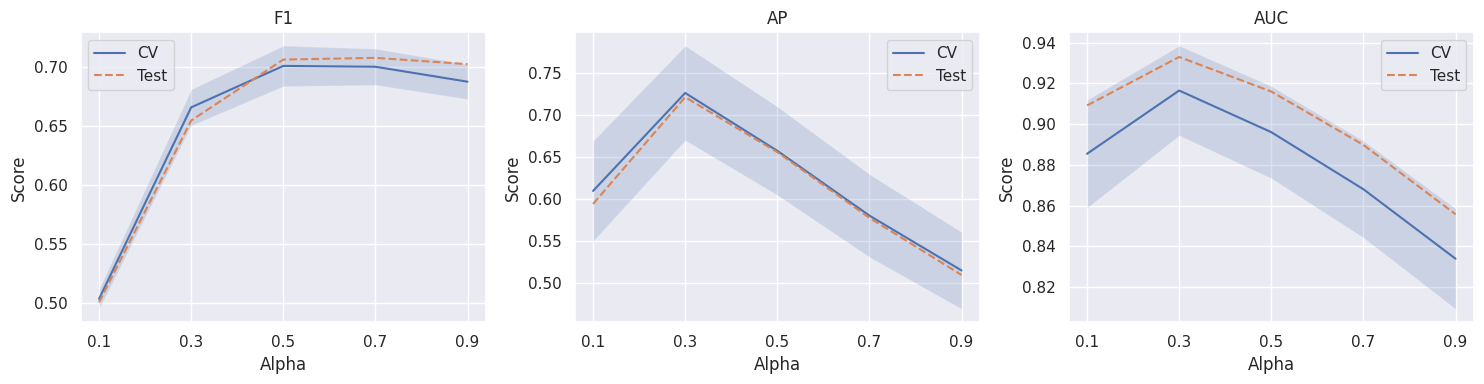

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()
titles = ["F1", "AP", "AUC"]

# F1
axes[0].plot(alphas, f1_mean, label="CV")
axes[0].fill_between(alphas, f1_mean - f1_std, f1_mean + f1_std, alpha=0.2)
axes[0].plot(alphas, f1_lst_test, label="Test", linestyle="--")

# AP
axes[1].plot(alphas, ap_mean, label="CV")
axes[1].fill_between(alphas, ap_mean - ap_std, ap_mean + ap_std, alpha=0.2)
axes[1].plot(alphas, ap_lst_test, label="Test", linestyle="--")

# AUC
axes[2].plot(alphas, auc_mean, label="CV")
axes[2].fill_between(alphas, auc_mean - auc_std, auc_mean + auc_std, alpha=0.2)
axes[2].plot(alphas, auc_lst_test, label="Test", linestyle="--")

for i, ax in enumerate(axes):
    ax.set_title(titles[i])
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Score")
    ax.set_xticks(alphas)
    ax.legend()

plt.tight_layout()
plt.show()

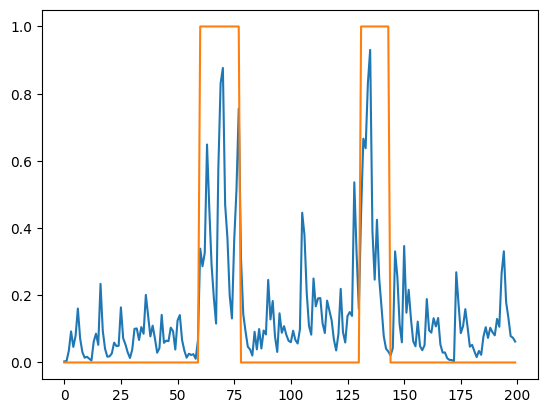

In [68]:
plt.plot(final_probs[:200])
plt.plot(y_val[:200])

In [ ]:
# length of the differences for a window
import numpy as np

# Find where value changes
change_points = np.diff(alllabs) != 0

# Indices where runs end
run_ends = np.where(change_points)[0] + 1

# Add start and end to split
run_lengths = np.diff(np.r_[0, run_ends, len(alllabs)])

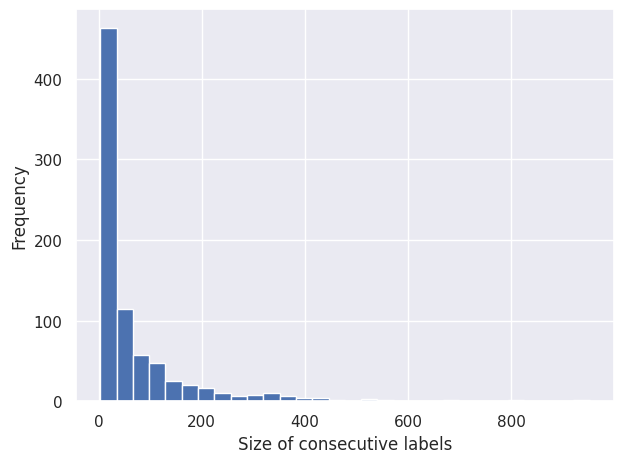

In [139]:
plt.hist(run_lengths, bins=30)
plt.ylabel("Frequency")
plt.xlabel("Size of consecutive labels")
plt.tight_layout()
plt.savefig("images/pretest/len_dist.pdf")

In [15]:
# other smoothing
import numpy as np
from scipy.signal.windows import gaussian

def mean_std_per_fold(lst, fold_size=5):
    means = []
    stds = []
    for i in range(0, len(lst), fold_size):
        fold_group = lst[i:i+fold_size]
        mean_val = np.mean(fold_group)
        std_val = np.std(fold_group)
        means.append(mean_val)
        stds.append(std_val)
    return np.array(means), np.array(stds)

def sequential_smoothing(probs, alpha=0.7):
    """
    exponential smoothing
    Adjusts the current probability based on the previous one.
    P_smooth = (alpha * current_prob) + ((1 - alpha) * previous_prob)
    """
    smoothed_probs = np.zeros_like(probs)
    smoothed_probs[0] = probs[0] # First one stays the same
    
    for t in range(1, len(probs)):
        smoothed_probs[t] = (alpha * probs[t]) + ((1 - alpha) * smoothed_probs[t-1])
    
    return smoothed_probs

def gaussian_moving_average(probs, window_size=10, std=1.0):
    """
    Smooth a sequence of probabilities using a Gaussian-weighted moving average.
    
    Args:
        probs (list or np.array): sequence of probabilities
        window_size (int): number of points in the window
        std (float): standard deviation of the Gaussian

    Returns:
        np.array: smoothed sequence
    """
    # Generate Gaussian weights
    weights = gaussian(window_size, std=std)
    weights /= weights.sum()  # normalize to sum to 1
    
    # Apply weighted moving average
    smoothed = np.convolve(probs, weights, mode='same')
    return smoothed

def moving_average(probs, window=3):
    smoothed = np.convolve(probs, np.ones(window)/window, mode='same')
    return smoothed

### Gaussian smoothing

In [16]:
import seaborn as sns 

def train_smooth_gauss(alphas, std=1):
    # grid search over alpha

    window_size = alphas
    ap_lst = []
    f1_lst = []
    auc_lst = []

    ap_lst_test = []
    f1_lst_test = []
    auc_lst_test = []

    tscv = TimeSeriesSplit(n_splits=5)

    for w in window_size:
        for train_index, test_index in tscv.split(X_train):
            X_train_sub, X_val = X_train[train_index], X_train[test_index]
            y_train_sub, y_val = y_train[train_index], y_train[test_index]
            
            X_train_vect = vectorizer.fit_transform(X_train_sub)
            X_val_vect = vectorizer.transform(X_val)
            
            clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
            clf.fit(X_train_vect, y_train_sub)

            raw_probs = clf.predict_proba(X_val_vect)[:, 1] # Get probabilities for the positive class
            
            final_probs = gaussian_moving_average(raw_probs, window_size=w, std=std)
            
            y_pred = (final_probs > 0.5).astype(int)

            f1 = f1_score(y_val, y_pred, average='macro')    
            ap = average_precision_score(y_val, final_probs)
            auc = roc_auc_score(y_val, final_probs)

            f1_lst.append(f1)
            ap_lst.append(ap)
            auc_lst.append(auc)

            print(f"Fold Average Precision: {ap:.4f}")
            print(f"Fold F1 Score: {f1:.4f}")
            print(f"Fold AUC Score: {auc:.4f}")

        # training on all train, then test
        X_train_vect = vectorizer.fit_transform(X_train)
        X_test_vect = vectorizer.transform(X_test)
        
        clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
        clf.fit(X_train_vect, y_train)

        raw_probs = clf.predict_proba(X_test_vect)[:, 1] # Get probabilities for the positive class
        final_probs = gaussian_moving_average(raw_probs, window_size=w, std=std)
        
        y_pred = (final_probs > 0.5).astype(int)

        f1 = f1_score(y_test, y_pred, average='macro')    
        ap = average_precision_score(y_test, final_probs)
        auc = roc_auc_score(y_test, final_probs)

        f1_lst_test.append(f1)
        ap_lst_test.append(ap)
        auc_lst_test.append(auc)

        print(f"Test Average Precision: {ap:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test AUC Score: {auc:.4f}")

    return ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test 

def plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test, alphas):
    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes = axes.flatten()
    titles = ["F1", "AP", "AUC"]

    # F1
    axes[0].plot(alphas, f1_mean, label="CV")
    axes[0].fill_between(alphas, f1_mean - f1_std, f1_mean + f1_std, alpha=0.2)
    axes[0].plot(alphas, f1_lst_test, label="Test", linestyle="--")

    # AP
    axes[1].plot(alphas, ap_mean, label="CV")
    axes[1].fill_between(alphas, ap_mean - ap_std, ap_mean + ap_std, alpha=0.2)
    axes[1].plot(alphas, ap_lst_test, label="Test", linestyle="--")

    # AUC
    axes[2].plot(alphas, auc_mean, label="CV")
    axes[2].fill_between(alphas, auc_mean - auc_std, auc_mean + auc_std, alpha=0.2)
    axes[2].plot(alphas, auc_lst_test, label="Test", linestyle="--")

    for i, ax in enumerate(axes):
        ax.set_title(titles[i])
        ax.set_xlabel("Alpha")
        ax.set_ylabel("Score")
        ax.set_xticks(alphas)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test = train_smooth_gauss(alphas = [5, 10, 15, 20])

f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

In [17]:
def plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test, alphas):
    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes = axes.flatten()
    titles = ["F1", "AP", "AUC"]

    # F1
    axes[0].plot(alphas, f1_mean, label="CV")
    axes[0].fill_between(alphas, f1_mean - f1_std, f1_mean + f1_std, alpha=0.2)
    axes[0].plot(alphas, f1_lst_test, label="Test", linestyle="--")

    # AP
    axes[1].plot(alphas, ap_mean, label="CV")
    axes[1].fill_between(alphas, ap_mean - ap_std, ap_mean + ap_std, alpha=0.2)
    axes[1].plot(alphas, ap_lst_test, label="Test", linestyle="--")

    # AUC
    axes[2].plot(alphas, auc_mean, label="CV")
    axes[2].fill_between(alphas, auc_mean - auc_std, auc_mean + auc_std, alpha=0.2)
    axes[2].plot(alphas, auc_lst_test, label="Test", linestyle="--")

    for i, ax in enumerate(axes):
        ax.set_title(titles[i])
        ax.set_xlabel("Alpha")
        ax.set_ylabel("Score")
        ax.set_xticks(alphas)
        ax.legend()

    plt.tight_layout()
    plt.show()

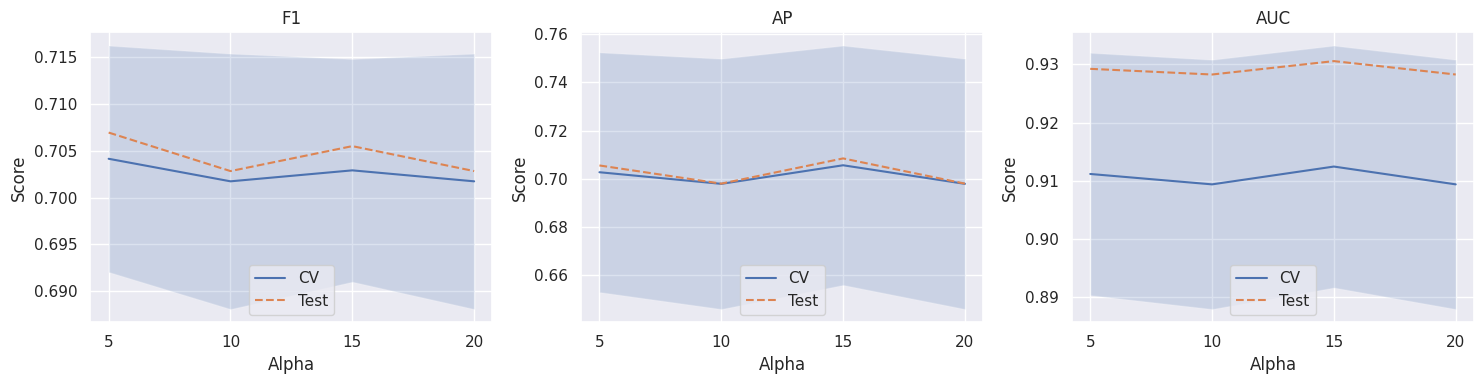

In [18]:
plot_cv_smooth(ap_mean, f1_mean, auc_mean, ap_lst_test, f1_lst_test, auc_lst_test, alphas = [5, 10, 15, 20])

Fold Average Precision: 0.6247
Fold F1 Score: 0.6814
Fold AUC Score: 0.8716
Fold Average Precision: 0.7706
Fold F1 Score: 0.7127
Fold AUC Score: 0.9208
Fold Average Precision: 0.7343
Fold F1 Score: 0.7049
Fold AUC Score: 0.9216
Fold Average Precision: 0.6760
Fold F1 Score: 0.7058
Fold AUC Score: 0.9105
Fold Average Precision: 0.7078
Fold F1 Score: 0.7160
Fold AUC Score: 0.9313
Test Average Precision: 0.7055
Test F1 Score: 0.7070
Test AUC Score: 0.9293
Fold Average Precision: 0.6192
Fold F1 Score: 0.6754
Fold AUC Score: 0.8689
Fold Average Precision: 0.7703
Fold F1 Score: 0.7124
Fold AUC Score: 0.9195
Fold Average Precision: 0.7316
Fold F1 Score: 0.7030
Fold AUC Score: 0.9212
Fold Average Precision: 0.6666
Fold F1 Score: 0.7123
Fold AUC Score: 0.9075
Fold Average Precision: 0.7015
Fold F1 Score: 0.7055
Fold AUC Score: 0.9298
Test Average Precision: 0.6979
Test F1 Score: 0.7028
Test AUC Score: 0.9283
Fold Average Precision: 0.6275
Fold F1 Score: 0.6800
Fold AUC Score: 0.8729
Fold Average

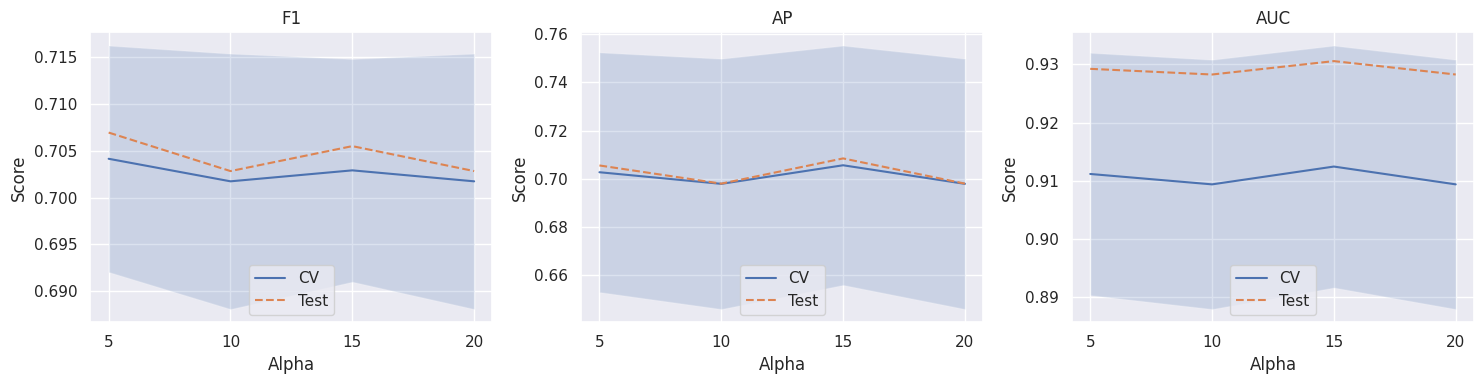

In [158]:
ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test = train_smooth_gauss(alphas = [5, 10, 15, 20])

f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

plot_cv_smooth(ap_mean, f1_mean, auc_mean, ap_lst_test, f1_lst_test, auc_lst_test, alphas = [5, 10, 15, 20])

Fold Average Precision: 0.7160
Fold F1 Score: 0.6519
Fold AUC Score: 0.9072
Fold Average Precision: 0.8605
Fold F1 Score: 0.6816
Fold AUC Score: 0.9505
Fold Average Precision: 0.8314
Fold F1 Score: 0.6686
Fold AUC Score: 0.9517
Fold Average Precision: 0.7865
Fold F1 Score: 0.6632
Fold AUC Score: 0.9459
Fold Average Precision: 0.8231
Fold F1 Score: 0.6812
Fold AUC Score: 0.9631
Test Average Precision: 0.8027
Test F1 Score: 0.6600
Test AUC Score: 0.9602
Fold Average Precision: 0.7160
Fold F1 Score: 0.6519
Fold AUC Score: 0.9072
Fold Average Precision: 0.8605
Fold F1 Score: 0.6816
Fold AUC Score: 0.9505
Fold Average Precision: 0.8314
Fold F1 Score: 0.6686
Fold AUC Score: 0.9517
Fold Average Precision: 0.7865
Fold F1 Score: 0.6632
Fold AUC Score: 0.9459
Fold Average Precision: 0.8231
Fold F1 Score: 0.6812
Fold AUC Score: 0.9631
Test Average Precision: 0.8027
Test F1 Score: 0.6600
Test AUC Score: 0.9602


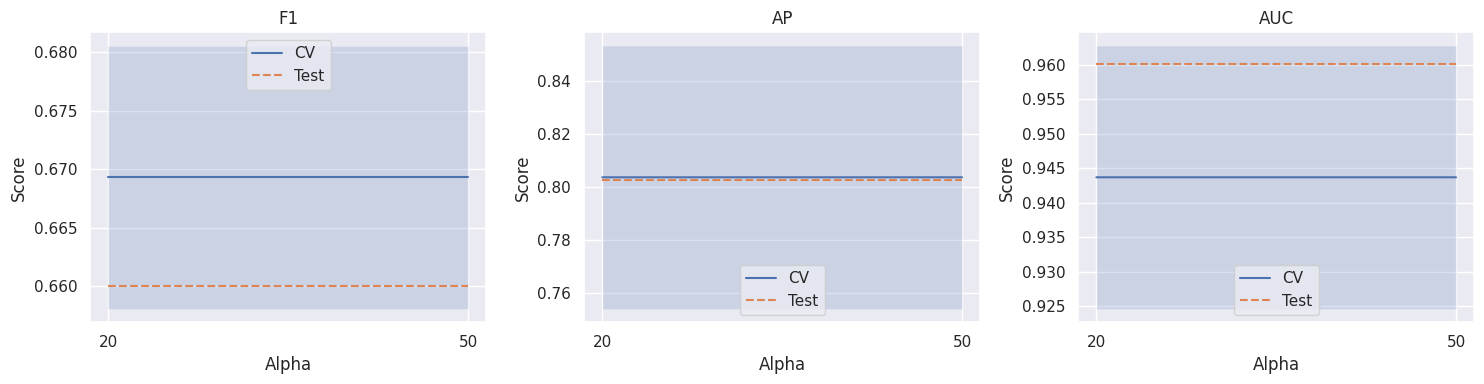

In [164]:
ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test = train_smooth_gauss(std=2, alphas = [20, 50])

f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

plot_cv_smooth(ap_mean, f1_mean, auc_mean, ap_lst_test, f1_lst_test, auc_lst_test, alphas = [20, 50])

Fold Average Precision: 0.6735
Fold F1 Score: 0.6723
Fold AUC Score: 0.8897
Fold Average Precision: 0.8193
Fold F1 Score: 0.7064
Fold AUC Score: 0.9361
Fold Average Precision: 0.7865
Fold F1 Score: 0.6858
Fold AUC Score: 0.9364
Fold Average Precision: 0.7379
Fold F1 Score: 0.6891
Fold AUC Score: 0.9282
Fold Average Precision: 0.7734
Fold F1 Score: 0.7063
Fold AUC Score: 0.9464
Test Average Precision: 0.7597
Test F1 Score: 0.6810
Test AUC Score: 0.9442
Fold Average Precision: 0.7138
Fold F1 Score: 0.6512
Fold AUC Score: 0.9062
Fold Average Precision: 0.8586
Fold F1 Score: 0.6854
Fold AUC Score: 0.9498
Fold Average Precision: 0.8293
Fold F1 Score: 0.6708
Fold AUC Score: 0.9510
Fold Average Precision: 0.7844
Fold F1 Score: 0.6695
Fold AUC Score: 0.9451
Fold Average Precision: 0.8209
Fold F1 Score: 0.6835
Fold AUC Score: 0.9625
Test Average Precision: 0.8006
Test F1 Score: 0.6624
Test AUC Score: 0.9595
Fold Average Precision: 0.7219
Fold F1 Score: 0.6559
Fold AUC Score: 0.9095
Fold Average

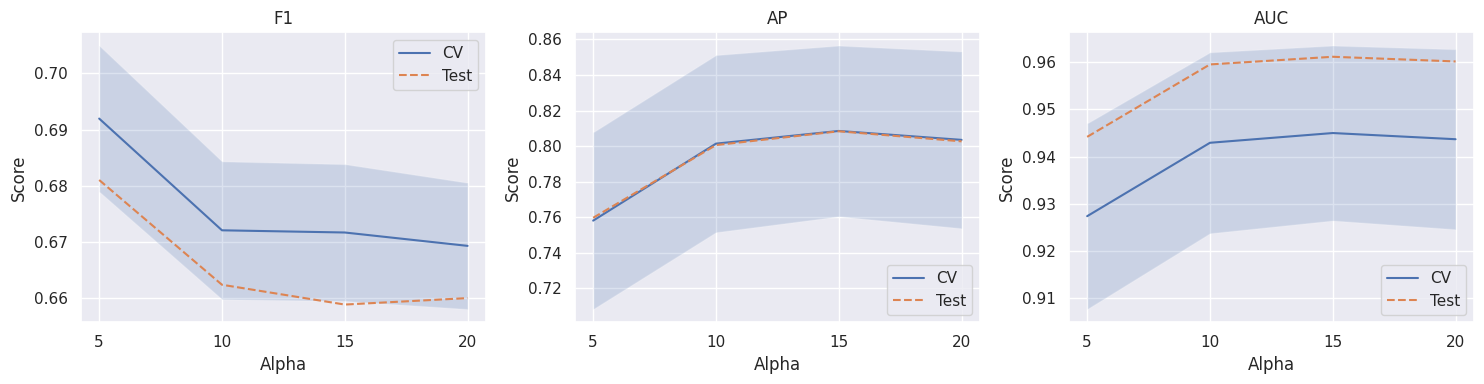

In [162]:
ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test = train_smooth_gauss(std = 2, alphas = [5, 10, 15, 20])
f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

plot_cv_smooth(ap_mean, f1_mean, auc_mean, ap_lst_test, f1_lst_test, auc_lst_test, alphas = [5, 10, 15, 20])

Fold Average Precision: 0.6764
Fold F1 Score: 0.6697
Fold AUC Score: 0.8904
Fold Average Precision: 0.8222
Fold F1 Score: 0.7018
Fold AUC Score: 0.9369
Fold Average Precision: 0.7899
Fold F1 Score: 0.6770
Fold AUC Score: 0.9369
Fold Average Precision: 0.7428
Fold F1 Score: 0.6919
Fold AUC Score: 0.9294
Fold Average Precision: 0.7793
Fold F1 Score: 0.7030
Fold AUC Score: 0.9476
Test Average Precision: 0.7633
Test F1 Score: 0.6756
Test AUC Score: 0.9449
Fold Average Precision: 0.7365
Fold F1 Score: 0.6326
Fold AUC Score: 0.9144
Fold Average Precision: 0.8778
Fold F1 Score: 0.6648
Fold AUC Score: 0.9553
Fold Average Precision: 0.8520
Fold F1 Score: 0.6588
Fold AUC Score: 0.9576
Fold Average Precision: 0.8115
Fold F1 Score: 0.6358
Fold AUC Score: 0.9538
Fold Average Precision: 0.8492
Fold F1 Score: 0.6632
Fold AUC Score: 0.9691
Test Average Precision: 0.8231
Test F1 Score: 0.6392
Test AUC Score: 0.9657
Fold Average Precision: 0.7541
Fold F1 Score: 0.6265
Fold AUC Score: 0.9216
Fold Average

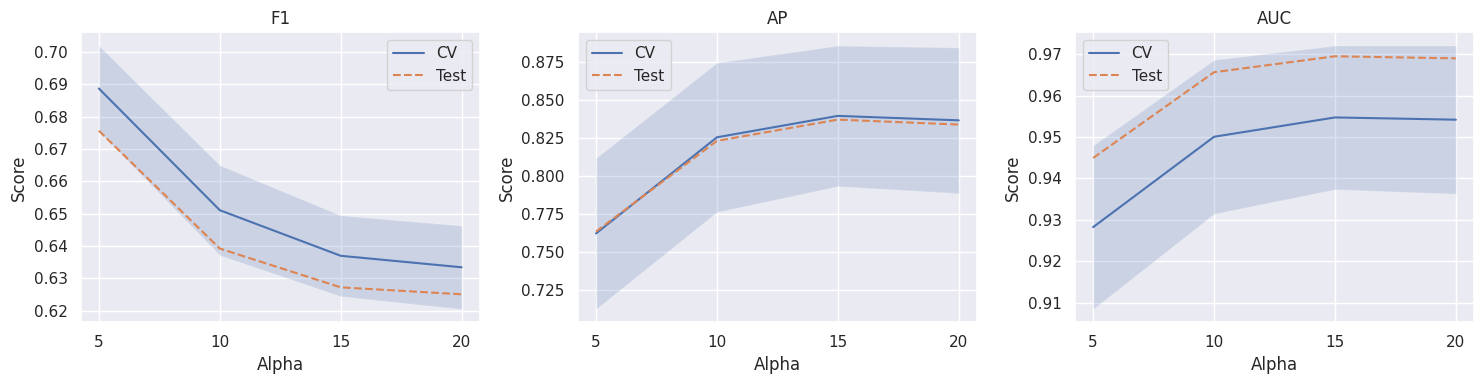

In [159]:
ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test = train_smooth_gauss(std = 3, alphas = [5, 10, 15, 20])
f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

plot_cv_smooth(ap_mean, f1_mean, auc_mean, ap_lst_test, f1_lst_test, auc_lst_test, alphas = [5, 10, 15, 20])

### Average window smoothing

In [166]:
def train_smooth_avg(alphas):
    # grid search over alpha

    window_size = alphas
    ap_lst = []
    f1_lst = []
    auc_lst = []

    ap_lst_test = []
    f1_lst_test = []
    auc_lst_test = []

    tscv = TimeSeriesSplit(n_splits=5)

    for w in window_size:
        for train_index, test_index in tscv.split(X_train):
            X_train_sub, X_val = X_train[train_index], X_train[test_index]
            y_train_sub, y_val = y_train[train_index], y_train[test_index]
            
            X_train_vect = vectorizer.fit_transform(X_train_sub)
            X_val_vect = vectorizer.transform(X_val)
            
            clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
            clf.fit(X_train_vect, y_train_sub)

            raw_probs = clf.predict_proba(X_val_vect)[:, 1] # Get probabilities for the positive class
            
            final_probs = moving_average(raw_probs, window=w)
            
            y_pred = (final_probs > 0.5).astype(int)

            f1 = f1_score(y_val, y_pred, average='macro')    
            ap = average_precision_score(y_val, final_probs)
            auc = roc_auc_score(y_val, final_probs)

            f1_lst.append(f1)
            ap_lst.append(ap)
            auc_lst.append(auc)

            print(f"Fold Average Precision: {ap:.4f}")
            print(f"Fold F1 Score: {f1:.4f}")
            print(f"Fold AUC Score: {auc:.4f}")

        # training on all train, then test
        X_train_vect = vectorizer.fit_transform(X_train)
        X_test_vect = vectorizer.transform(X_test)
        
        clf = build_model(name="logreg", solver="lbfgs", max_iter=1000)
        clf.fit(X_train_vect, y_train)

        raw_probs = clf.predict_proba(X_test_vect)[:, 1] # Get probabilities for the positive class
        final_probs = moving_average(raw_probs, window=w)
        
        y_pred = (final_probs > 0.5).astype(int)

        f1 = f1_score(y_test, y_pred, average='macro')    
        ap = average_precision_score(y_test, final_probs)
        auc = roc_auc_score(y_test, final_probs)

        f1_lst_test.append(f1)
        ap_lst_test.append(ap)
        auc_lst_test.append(auc)

        print(f"Test Average Precision: {ap:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test AUC Score: {auc:.4f}")

    return ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test 


Fold Average Precision: 0.6754
Fold F1 Score: 0.6661
Fold AUC Score: 0.8898
Fold Average Precision: 0.8215
Fold F1 Score: 0.7044
Fold AUC Score: 0.9367
Fold Average Precision: 0.7904
Fold F1 Score: 0.6759
Fold AUC Score: 0.9365
Fold Average Precision: 0.7425
Fold F1 Score: 0.6888
Fold AUC Score: 0.9292
Fold Average Precision: 0.7798
Fold F1 Score: 0.7084
Fold AUC Score: 0.9476
Test Average Precision: 0.7623
Test F1 Score: 0.6772
Test AUC Score: 0.9447
Fold Average Precision: 0.7338
Fold F1 Score: 0.6195
Fold AUC Score: 0.9137
Fold Average Precision: 0.8762
Fold F1 Score: 0.6541
Fold AUC Score: 0.9547
Fold Average Precision: 0.8543
Fold F1 Score: 0.6443
Fold AUC Score: 0.9581
Fold Average Precision: 0.8051
Fold F1 Score: 0.6139
Fold AUC Score: 0.9547
Fold Average Precision: 0.8501
Fold F1 Score: 0.6423
Fold AUC Score: 0.9691
Test Average Precision: 0.8197
Test F1 Score: 0.6254
Test AUC Score: 0.9649
Fold Average Precision: 0.7456
Fold F1 Score: 0.5594
Fold AUC Score: 0.9209
Fold Average

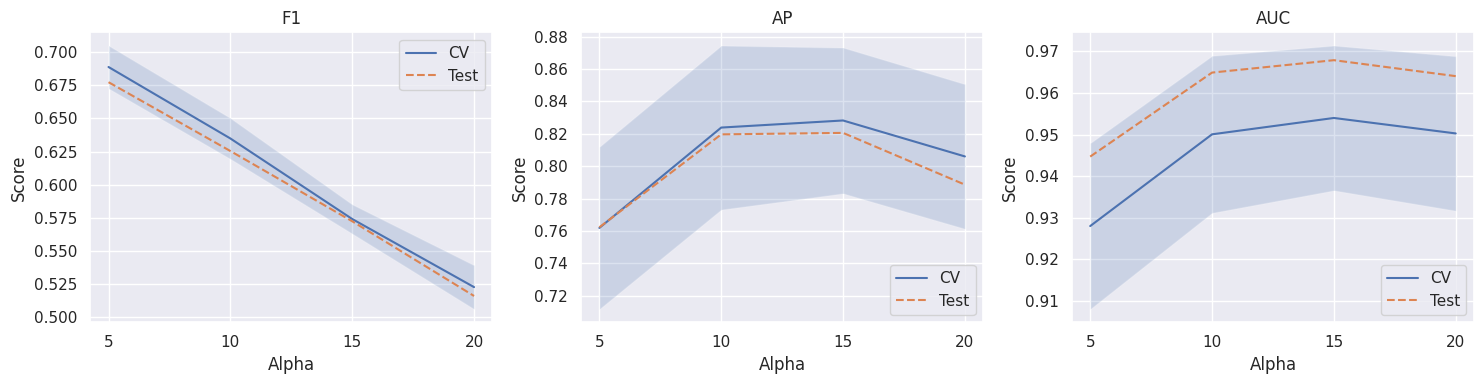

In [161]:
ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test = train_smooth_avg(alphas = [5, 10, 15, 20])
f1_mean, f1_std = mean_std_per_fold(f1_lst)
ap_mean, ap_std = mean_std_per_fold(ap_lst)
auc_mean, auc_std = mean_std_per_fold(auc_lst)

plot_cv_smooth(ap_mean, f1_mean, auc_mean, ap_lst_test, f1_lst_test, auc_lst_test, alphas = [5, 10, 15, 20])

### proper plots

In [13]:
# other smoothing
import numpy as np
from scipy.signal.windows import gaussian

def mean_std_per_fold(lst, fold_size=5):
    means = []
    stds = []
    for i in range(0, len(lst), fold_size):
        fold_group = lst[i:i+fold_size]
        mean_val = np.mean(fold_group)
        std_val = np.std(fold_group)
        means.append(mean_val)
        stds.append(std_val)
    return np.array(means), np.array(stds)

def sequential_smoothing(probs, alpha=0.7):
    """
    exponential smoothing
    Adjusts the current probability based on the previous one.
    P_smooth = (alpha * current_prob) + ((1 - alpha) * previous_prob)
    """
    smoothed_probs = np.zeros_like(probs)
    smoothed_probs[0] = probs[0] # First one stays the same
    
    for t in range(1, len(probs)):
        smoothed_probs[t] = (alpha * probs[t]) + ((1 - alpha) * smoothed_probs[t-1])
    
    return smoothed_probs

def gaussian_moving_average(probs, window_size=10, std=1.0):
    """
    Smooth a sequence of probabilities using a Gaussian-weighted moving average.
    
    Args:
        probs (list or np.array): sequence of probabilities
        window_size (int): number of points in the window
        std (float): standard deviation of the Gaussian

    Returns:
        np.array: smoothed sequence
    """
    # Generate Gaussian weights
    weights = gaussian(window_size, std=std)
    weights /= weights.sum()  # normalize to sum to 1
    
    # Apply weighted moving average
    smoothed = np.convolve(probs, weights, mode='same')
    return smoothed

def moving_average(probs, window=3):
    smoothed = np.convolve(probs, np.ones(window)/window, mode='same')
    return smoothed

In [21]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
import numpy as np

def train_with_smoothing(
    smoothing_func, 
    smoothing_params_list, 
    X_train, y_train, X_test, y_test, 
    vectorizer, 
    model_name="logreg",
    model_params=None,
    tscv_splits=5,
    return_probs = False
):
    if model_params is None:
        model_params = {"solver": "lbfgs", "max_iter": 1000}

    ap_lst, f1_lst, auc_lst = [], [], []
    ap_lst_test, f1_lst_test, auc_lst_test = [], [], []

    tscv = TimeSeriesSplit(n_splits=tscv_splits)

    for param in smoothing_params_list:
        # Cross-validation
        for train_index, val_index in tscv.split(X_train):
            X_train_sub, X_val = X_train[train_index], X_train[val_index]
            y_train_sub, y_val = y_train[train_index], y_train[val_index]

            X_train_vect = vectorizer.fit_transform(X_train_sub)
            X_val_vect = vectorizer.transform(X_val)

            clf = build_model(name=model_name, **model_params)
            clf.fit(X_train_vect, y_train_sub)

            raw_probs = clf.predict_proba(X_val_vect)[:, 1]
            final_probs = smoothing_func(raw_probs, param)

            y_pred = (final_probs > 0.5).astype(int)
            f1 = f1_score(y_val, y_pred, average='macro')
            ap = average_precision_score(y_val, final_probs)
            auc = roc_auc_score(y_val, final_probs)

            f1_lst.append(f1)
            ap_lst.append(ap)
            auc_lst.append(auc)

            print(f"Fold Average Precision: {ap:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

        # Train on full training set, evaluate on test
        X_train_vect = vectorizer.fit_transform(X_train)
        X_test_vect = vectorizer.transform(X_test)

        clf = build_model(name=model_name, **model_params)
        clf.fit(X_train_vect, y_train)

        raw_probs = clf.predict_proba(X_test_vect)[:, 1]
        final_probs = smoothing_func(raw_probs, param)

        y_pred = (final_probs > 0.5).astype(int)
        f1 = f1_score(y_test, y_pred, average='macro')
        ap = average_precision_score(y_test, final_probs)
        auc = roc_auc_score(y_test, final_probs)

        f1_lst_test.append(f1)
        ap_lst_test.append(ap)
        auc_lst_test.append(auc)

        print(f"Test Average Precision: {ap:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    if return_probs:
        return ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test, raw_probs
    return ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test


def plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test, alphas, fold_size=5, title="", xlab="Alpha"):
    # Compute mean and std per fold
    f1_mean, f1_std = mean_std_per_fold(f1_lst, fold_size)
    ap_mean, ap_std = mean_std_per_fold(ap_lst, fold_size)
    auc_mean, auc_std = mean_std_per_fold(auc_lst, fold_size)

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes = axes.flatten()
    titles = ["F1", "AP", "AUC"]

    # F1
    axes[0].plot(alphas, f1_mean, label="CV", marker="o")
    axes[0].fill_between(alphas, f1_mean - f1_std, f1_mean + f1_std, alpha=0.2)
    axes[0].plot(alphas, f1_lst_test, label="Test", linestyle="--", marker="o")

    # AP
    axes[1].plot(alphas, ap_mean, label="CV", marker="o")
    axes[1].fill_between(alphas, ap_mean - ap_std, ap_mean + ap_std, alpha=0.2)
    axes[1].plot(alphas, ap_lst_test, label="Test", linestyle="--", marker="o")

    # AUC
    axes[2].plot(alphas, auc_mean, label="CV", marker="o")
    axes[2].fill_between(alphas, auc_mean - auc_std, auc_mean + auc_std, alpha=0.2)
    axes[2].plot(alphas, auc_lst_test, label="Test", linestyle="--", marker="o")

    for i, ax in enumerate(axes):
        ax.set_title(titles[i])
        ax.set_xlabel(xlab)
        ax.set_ylabel("Score")
        ax.set_xticks(alphas)
        ax.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"images/smooth{title}.pdf")
    plt.show()

In [22]:
ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, probs_preds = train_with_smoothing(
    smoothing_func=lambda probs, alpha: sequential_smoothing(probs, alpha=alpha),
    smoothing_params_list=[0.1, 0.3, 0.5, 0.7, 0.9],
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer,
    return_probs=True
)

Fold Average Precision: 0.5242, F1: 0.4908, AUC: 0.8339
Fold Average Precision: 0.6793, F1: 0.5115, AUC: 0.8939
Fold Average Precision: 0.6694, F1: 0.5071, AUC: 0.9035
Fold Average Precision: 0.5616, F1: 0.4950, AUC: 0.8896
Fold Average Precision: 0.6127, F1: 0.5113, AUC: 0.9066
Test Average Precision: 0.5939, F1: 0.5003, AUC: 0.9092
Fold Average Precision: 0.6383, F1: 0.6406, AUC: 0.8738
Fold Average Precision: 0.7983, F1: 0.6802, AUC: 0.9265
Fold Average Precision: 0.7677, F1: 0.6729, AUC: 0.9319
Fold Average Precision: 0.6904, F1: 0.6545, AUC: 0.9172
Fold Average Precision: 0.7379, F1: 0.6789, AUC: 0.9332
Test Average Precision: 0.7214, F1: 0.6543, AUC: 0.9330
Fold Average Precision: 0.5811, F1: 0.6691, AUC: 0.8527
Fold Average Precision: 0.7318, F1: 0.7193, AUC: 0.9072
Fold Average Precision: 0.6958, F1: 0.7091, AUC: 0.9101
Fold Average Precision: 0.6222, F1: 0.6967, AUC: 0.8952
Fold Average Precision: 0.6560, F1: 0.7084, AUC: 0.9152
Test Average Precision: 0.6558, F1: 0.7059, AUC:

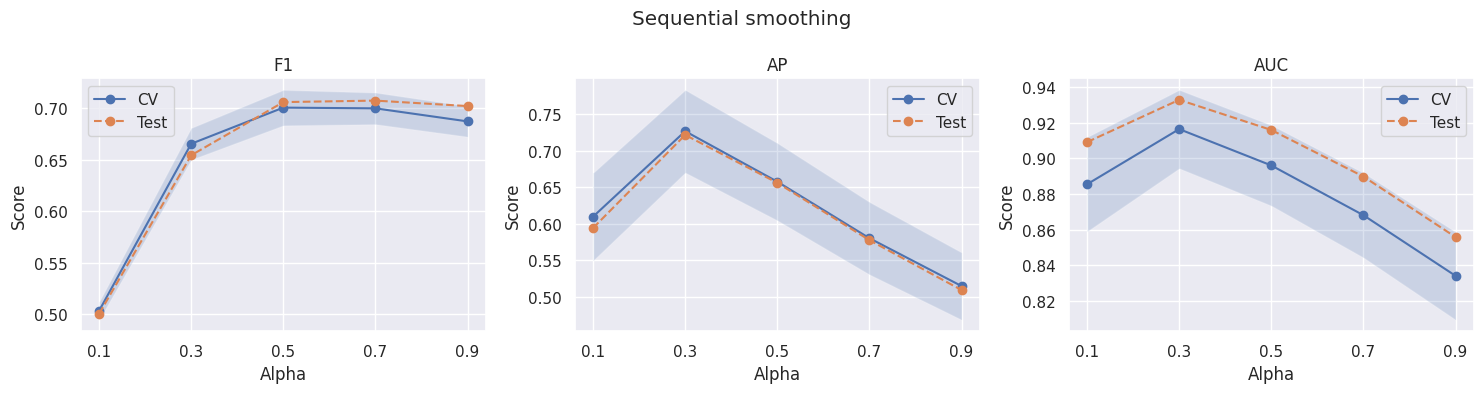

In [24]:
import seaborn as sns

plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test,alphas = [0.1, 0.3, 0.5, 0.7, 0.9], title="Sequential smoothing")

In [42]:
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

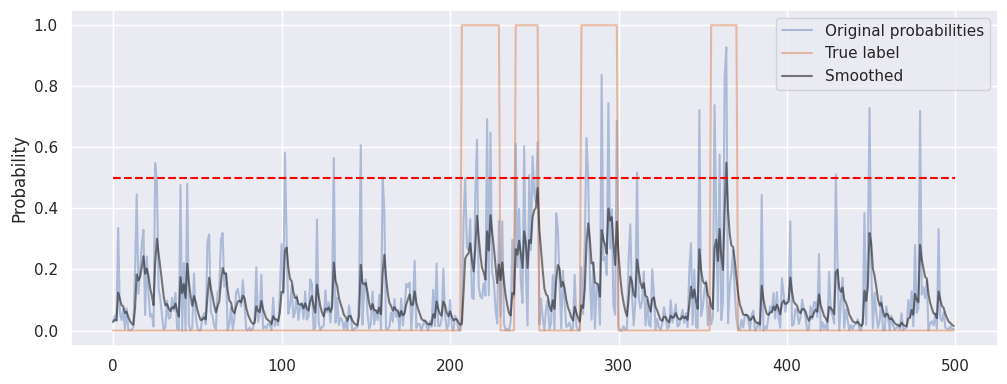

In [ ]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
plt.plot(sequential_smoothing(probs_preds[i:i+500], 0.3), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
plt.savefig("images/smoothed_vs_original_seq_05_alpha.pdf")
plt.legend()

In [50]:
ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, probs_preds = train_with_smoothing(
    smoothing_func=lambda probs, w: moving_average(probs, window=w),
    smoothing_params_list=[5, 10, 15, 20, 25],  # example window sizes
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer,
    return_probs=True
)

Fold Average Precision: 0.6754, F1: 0.6661, AUC: 0.8898
Fold Average Precision: 0.8215, F1: 0.7044, AUC: 0.9367
Fold Average Precision: 0.7904, F1: 0.6759, AUC: 0.9365
Fold Average Precision: 0.7425, F1: 0.6888, AUC: 0.9292
Fold Average Precision: 0.7798, F1: 0.7084, AUC: 0.9476
Test Average Precision: 0.7623, F1: 0.6772, AUC: 0.9447
Fold Average Precision: 0.7338, F1: 0.6195, AUC: 0.9137
Fold Average Precision: 0.8762, F1: 0.6541, AUC: 0.9547
Fold Average Precision: 0.8543, F1: 0.6443, AUC: 0.9581
Fold Average Precision: 0.8051, F1: 0.6139, AUC: 0.9547
Fold Average Precision: 0.8501, F1: 0.6423, AUC: 0.9691
Test Average Precision: 0.8197, F1: 0.6254, AUC: 0.9649
Fold Average Precision: 0.7456, F1: 0.5594, AUC: 0.9209
Fold Average Precision: 0.8699, F1: 0.5859, AUC: 0.9549
Fold Average Precision: 0.8600, F1: 0.5810, AUC: 0.9607
Fold Average Precision: 0.8167, F1: 0.5622, AUC: 0.9614
Fold Average Precision: 0.8492, F1: 0.5821, AUC: 0.9721
Test Average Precision: 0.8206, F1: 0.5724, AUC:

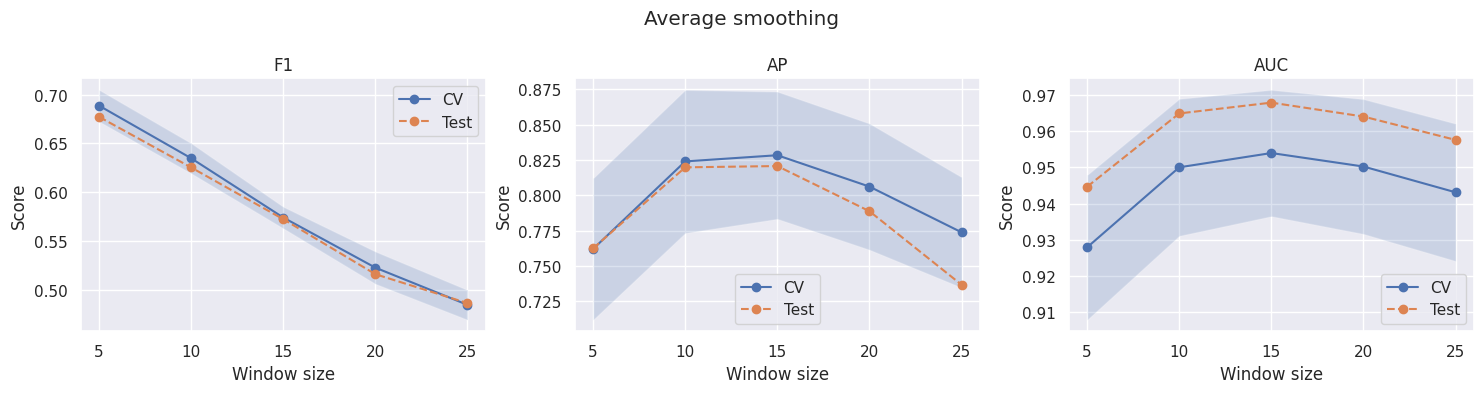

In [51]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title="Average smoothing", xlab="Window size")

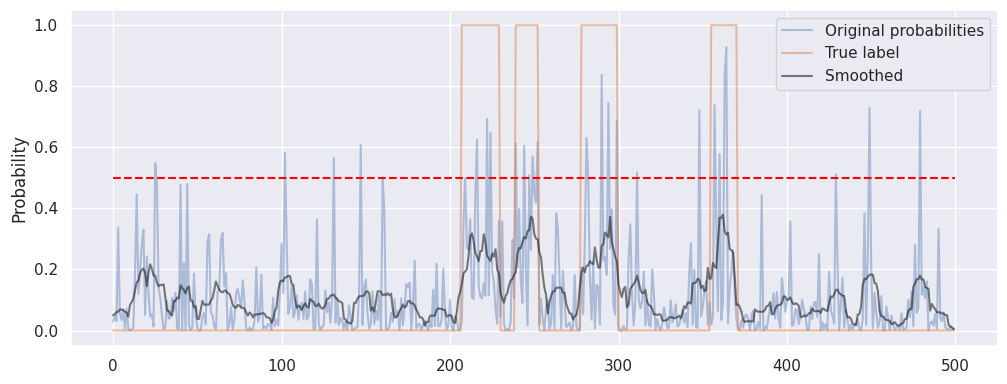

In [56]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
plt.plot(moving_average(probs_preds[i:i+500], window=10), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
plt.savefig("images/smoothed_vs_original_avg_smooth_10.pdf")
plt.legend()

In [57]:
std_val = 1

ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, probs_preds = train_with_smoothing(
    smoothing_func=lambda probs, w: gaussian_moving_average(probs, window_size=w, std=std_val),
    smoothing_params_list=[5, 10, 15, 20, 25],
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer,
    return_probs=True
)

Fold Average Precision: 0.6247, F1: 0.6814, AUC: 0.8716
Fold Average Precision: 0.7706, F1: 0.7127, AUC: 0.9208
Fold Average Precision: 0.7343, F1: 0.7049, AUC: 0.9216
Fold Average Precision: 0.6760, F1: 0.7058, AUC: 0.9105
Fold Average Precision: 0.7078, F1: 0.7160, AUC: 0.9313
Test Average Precision: 0.7055, F1: 0.7070, AUC: 0.9293
Fold Average Precision: 0.6192, F1: 0.6754, AUC: 0.8689
Fold Average Precision: 0.7703, F1: 0.7124, AUC: 0.9195
Fold Average Precision: 0.7316, F1: 0.7030, AUC: 0.9212
Fold Average Precision: 0.6666, F1: 0.7123, AUC: 0.9075
Fold Average Precision: 0.7015, F1: 0.7055, AUC: 0.9298
Test Average Precision: 0.6979, F1: 0.7028, AUC: 0.9283
Fold Average Precision: 0.6275, F1: 0.6800, AUC: 0.8729
Fold Average Precision: 0.7732, F1: 0.7120, AUC: 0.9219
Fold Average Precision: 0.7370, F1: 0.7049, AUC: 0.9227
Fold Average Precision: 0.6790, F1: 0.7048, AUC: 0.9119
Fold Average Precision: 0.7112, F1: 0.7128, AUC: 0.9327
Test Average Precision: 0.7084, F1: 0.7055, AUC:

In [ ]:
def plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_lst_test, f1_lst_test, auc_lst_test, alphas, fold_size=5, title="", xlab="Alpha", resize=False):
    # Compute mean and std per fold
    f1_mean, f1_std = mean_std_per_fold(f1_lst, fold_size)
    ap_mean, ap_std = mean_std_per_fold(ap_lst, fold_size)
    auc_mean, auc_std = mean_std_per_fold(auc_lst, fold_size)

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = ["F1", "AP", "AUC"]
    
    means = [f1_mean, ap_mean, auc_mean]
    stds = [f1_std, ap_std, auc_std]
    tests = [f1_lst_test, ap_lst_test, auc_lst_test]

    for i, ax in enumerate(axes):
        ax.plot(alphas, means[i], label="CV", marker="o")
        ax.fill_between(alphas, means[i] - stds[i], means[i] + stds[i], alpha=0.2)
        ax.plot(alphas, tests[i], label="Test", linestyle="--", marker="o")

        lower_bound = np.min(means[i] - stds[i])
        upper_bound = np.max(means[i] + stds[i])
        
        if resize:
            ax.set_ylim(lower_bound - 0.1, upper_bound + 0.1)

        ax.set_title(titles[i])
        ax.set_xlabel(xlab)
        ax.set_ylabel("Score")
        ax.set_xticks(alphas)
        ax.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"images/smooth{title}.pdf")
    plt.show()

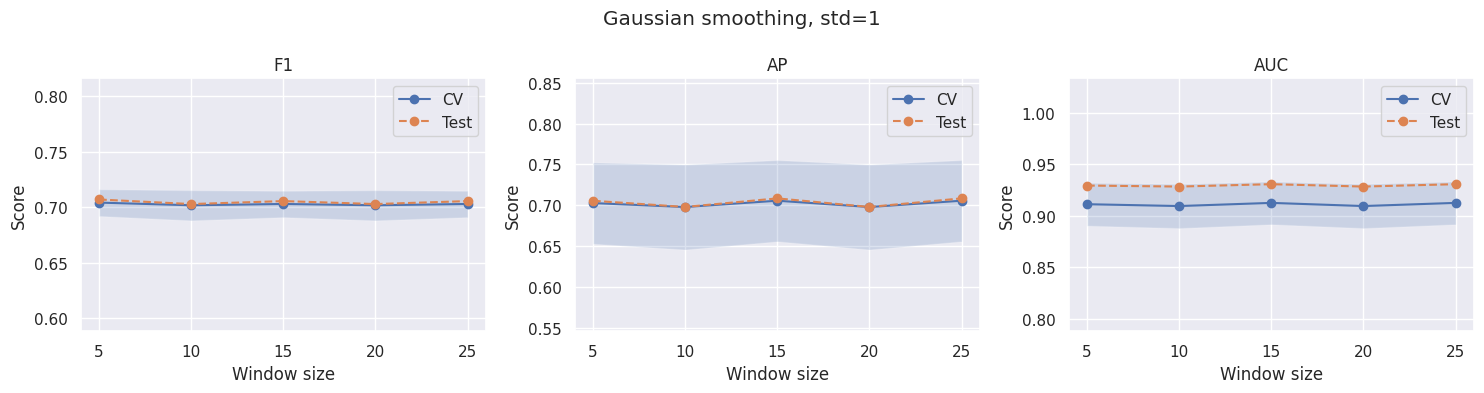

In [60]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing, std={std_val}", xlab="Window size", resize = True)

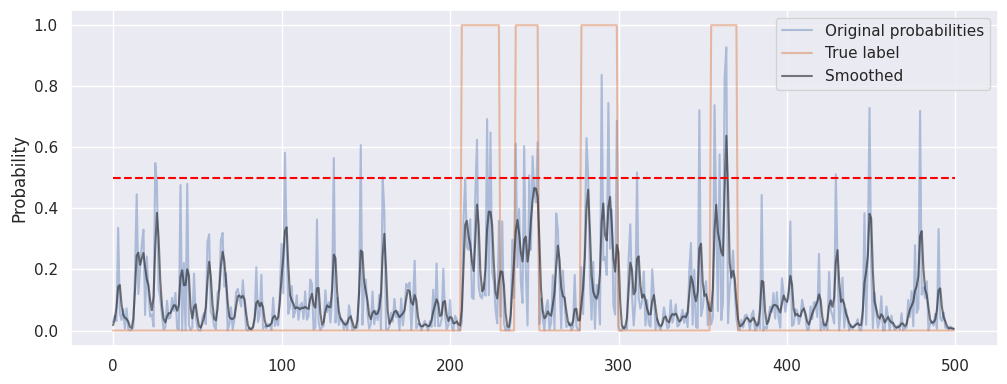

In [71]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
plt.plot(gaussian_moving_average(probs_preds[i:i+500], window_size=10, std=std_val), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
plt.savefig("images/smoothed_vs_original_gauss_std1_10.pdf")
plt.legend()

In [ ]:
std_val = 2

ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test = train_with_smoothing(
    smoothing_func=lambda probs, w: gaussian_moving_average(probs, window_size=w, std=std_val),
    smoothing_params_list=[5, 10, 15, 20, 25],
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer
)

Fold Average Precision: 0.6735, F1: 0.6723, AUC: 0.8897
Fold Average Precision: 0.8193, F1: 0.7064, AUC: 0.9361
Fold Average Precision: 0.7865, F1: 0.6858, AUC: 0.9364
Fold Average Precision: 0.7379, F1: 0.6891, AUC: 0.9282
Fold Average Precision: 0.7734, F1: 0.7063, AUC: 0.9464
Test Average Precision: 0.7597, F1: 0.6810, AUC: 0.9442
Fold Average Precision: 0.7138, F1: 0.6512, AUC: 0.9062
Fold Average Precision: 0.8586, F1: 0.6854, AUC: 0.9498
Fold Average Precision: 0.8293, F1: 0.6708, AUC: 0.9510
Fold Average Precision: 0.7844, F1: 0.6695, AUC: 0.9451
Fold Average Precision: 0.8209, F1: 0.6835, AUC: 0.9625
Test Average Precision: 0.8006, F1: 0.6624, AUC: 0.9595
Fold Average Precision: 0.7219, F1: 0.6559, AUC: 0.9095
Fold Average Precision: 0.8611, F1: 0.6802, AUC: 0.9512
Fold Average Precision: 0.8344, F1: 0.6674, AUC: 0.9522
Fold Average Precision: 0.7961, F1: 0.6646, AUC: 0.9480
Fold Average Precision: 0.8292, F1: 0.6904, AUC: 0.9641
Test Average Precision: 0.8083, F1: 0.6589, AUC:

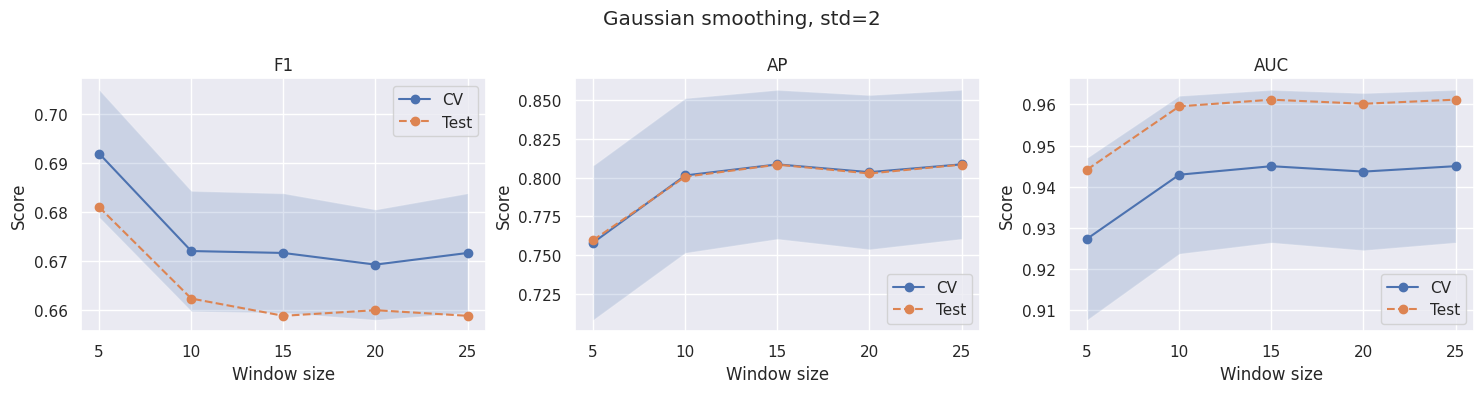

In [ ]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing, std={std_val}", xlab="Window size")

In [93]:
std_val = 5

ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, probs_preds = train_with_smoothing(
    smoothing_func=lambda probs, w: gaussian_moving_average(probs, window_size=w, std=std_val),
    smoothing_params_list=[5, 10, 15, 20, 25],
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer,
    return_probs=True
)

Fold Average Precision: 0.6762, F1: 0.6666, AUC: 0.8902
Fold Average Precision: 0.8223, F1: 0.7030, AUC: 0.9369
Fold Average Precision: 0.7906, F1: 0.6759, AUC: 0.9367
Fold Average Precision: 0.7432, F1: 0.6871, AUC: 0.9294
Fold Average Precision: 0.7799, F1: 0.7062, AUC: 0.9477
Test Average Precision: 0.7631, F1: 0.6746, AUC: 0.9449
Fold Average Precision: 0.7394, F1: 0.6262, AUC: 0.9154
Fold Average Precision: 0.8804, F1: 0.6541, AUC: 0.9558
Fold Average Precision: 0.8571, F1: 0.6397, AUC: 0.9590
Fold Average Precision: 0.8126, F1: 0.6230, AUC: 0.9555
Fold Average Precision: 0.8545, F1: 0.6546, AUC: 0.9701
Test Average Precision: 0.8252, F1: 0.6346, AUC: 0.9662
Fold Average Precision: 0.7608, F1: 0.5854, AUC: 0.9254
Fold Average Precision: 0.8874, F1: 0.6161, AUC: 0.9592
Fold Average Precision: 0.8718, F1: 0.6137, AUC: 0.9640
Fold Average Precision: 0.8347, F1: 0.5745, AUC: 0.9636
Fold Average Precision: 0.8686, F1: 0.6159, AUC: 0.9751
Test Average Precision: 0.8398, F1: 0.5910, AUC:

In [92]:
np.median(gaussian_moving_average(probs_preds, window_size=15, std=5))

np.float64(0.10222844028450594)

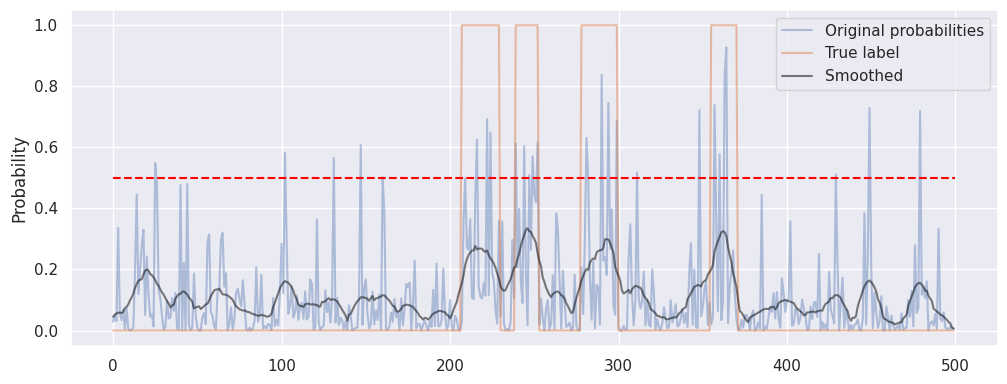

In [91]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
plt.plot(gaussian_moving_average(probs_preds[i:i+500], window_size=15, std=5), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
# plt.savefig("images/smoothed_vs_original_gauss_std3_10.pdf")
plt.legend()

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

clf = LogisticRegression()
clf.fit(probs_preds.reshape(-1,1), y_test)

p_adjusted = clf.predict_proba(probs_preds.reshape(-1,1))[:,1]

In [129]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=1)  # stump
clf.fit(probs_preds.reshape(-1,1), y_test)
p_adjusted = clf.predict_proba(probs_preds.reshape(-1,1))[:,1]

In [133]:
np.max(p_adjusted)

np.float64(0.5026833631484794)

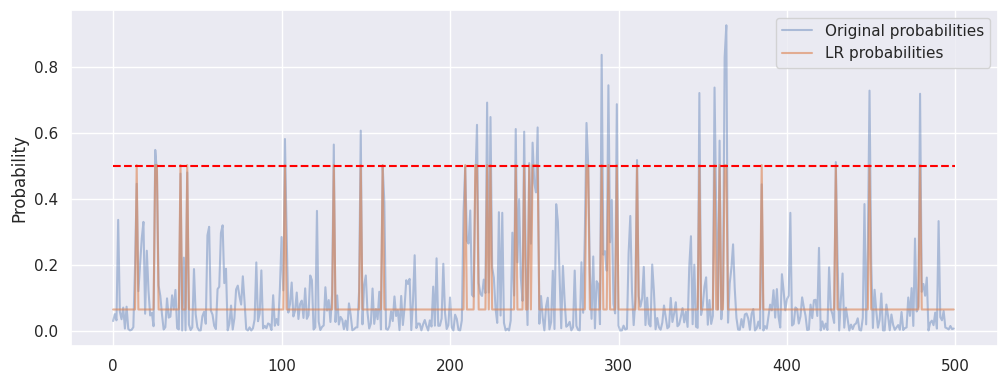

In [130]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(p_adjusted[i:i+500], label="LR probabilities", alpha=0.6)
# plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
# plt.plot(gaussian_moving_average(probs_preds[i:i+500], window_size=15, std=5), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
# plt.savefig("images/smoothed_vs_original_gauss_std3_10.pdf")
plt.legend()

In [141]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

smoothed = gaussian_filter1d(probs_preds, sigma=5, axis=0)
T = 0.3
logits_smoothed = np.log(smoothed + 1e-9)  # back to log space
resharpened = np.exp(logits_smoothed / T)
resharpened /= resharpened.sum()

In [148]:
from scipy.ndimage import median_filter

smoothed = median_filter(probs_preds, size=20)

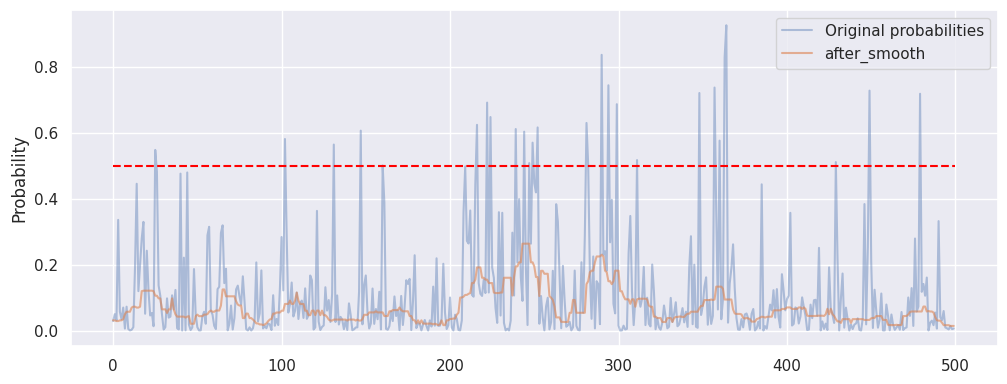

In [149]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(smoothed[i:i+500], label="after_smooth", alpha=0.6)
# plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
# plt.plot(gaussian_moving_average(probs_preds[i:i+500], window_size=15, std=5), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
# plt.savefig("images/smoothed_vs_original_gauss_std3_10.pdf")
plt.legend()

In [152]:
import torch
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, all_probs, all_labels):
        """
        all_probs:  list of np.arrays, each of shape [T]
        all_labels: list of np.arrays, each of shape [T]
        """
        self.probs  = [torch.tensor(p, dtype=torch.float32).unsqueeze(0) for p in all_probs]
        self.labels = [torch.tensor(l, dtype=torch.float32) for l in all_labels]

    def __len__(self):
        return len(self.probs)

    def __getitem__(self, idx):
        return self.probs[idx], self.labels[idx]

# Usage — just pass your lists directly
dataset = SequenceDataset(probs_preds, y_test)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)  # batch_size=1 because sequences have variable length

In [ ]:
import pandas as pd
df = pd.read_csv("Test_submission/pres/submission-pres-3.csv", header=None)
df.values

In [182]:
probs_sub3 = df.values.flatten()
probs_sub3

array([0.010642, 0.076628, 0.041422, ..., 0.011032, 0.008527, 0.032762],
      shape=(27162,))

In [186]:
np.save("probs_ytest.npy", probs_preds)

In [183]:
np.save("probs_sub3.npy", probs_sub3)

In [184]:
np.save("ytest.npy", y_test)

In [177]:
np.save("alllabs.npy", alllabs)

In [205]:
lstm_corr = np.load("corrected_probs.npy")
np.max(lstm_corr), np.min(lstm_corr), np.mean(lstm_corr)

(np.float32(0.9974113), np.float32(0.0046303775), np.float32(0.13938391))

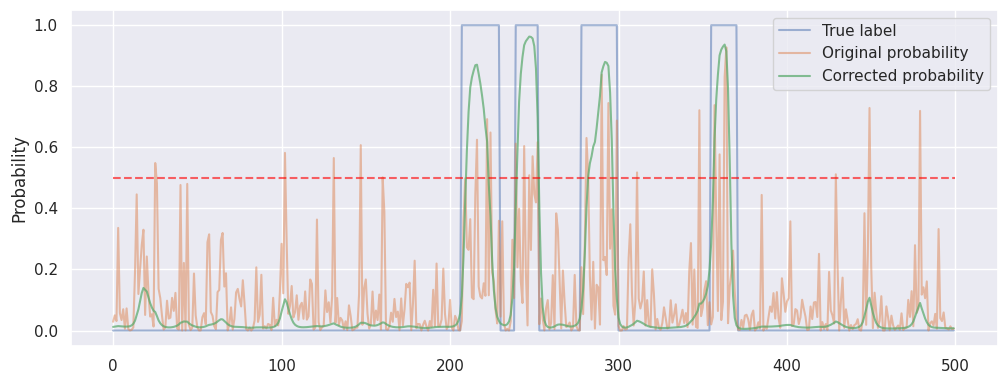

In [211]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(y_test[i:i+500], label="True label ", alpha=0.5)
plt.plot(probs_preds[i:i+500], label="Original probability", alpha=0.5)
plt.plot(lstm_corr[i:i+500], label="Corrected probability", alpha=0.7)
# plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
# plt.plot(gaussian_moving_average(probs_preds[i:i+500], window_size=15, std=5), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed', alpha = 0.6)
plt.tight_layout()
plt.ylabel("Probability")
plt.savefig("images/smoothing_test_quick.pdf")
plt.legend()
# windows 30

In [ ]:
0.821 


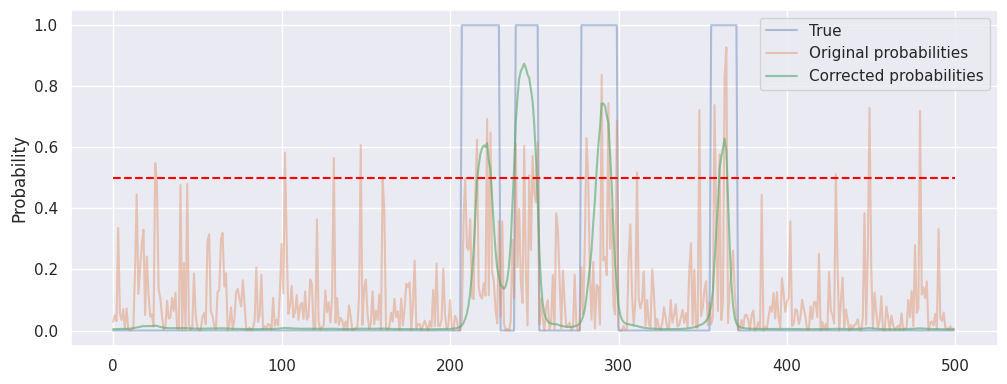

In [200]:
i = 500
plt.figure(figsize=(10, 4))
plt.plot(y_test[i:i+500], label="True", alpha=0.4)
plt.plot(probs_preds[i:i+500], label="Original probabilities", alpha=0.4)
plt.plot(lstm_corr[i:i+500], label="Corrected probabilities", alpha=0.6)
# plt.plot(y_test[i:i+500], label="True label", alpha=0.5)
# plt.plot(gaussian_moving_average(probs_preds[i:i+500], window_size=15, std=5), alpha=0.5, label="Smoothed", color="black")
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
plt.tight_layout()
plt.ylabel("Probability")
# plt.savefig("images/smoothed_vs_original_gauss_std3_10.pdf")
plt.legend()
# windows 20

In [201]:
# length of the differences for a window
import numpy as np

# Find where value changes
change_points = np.diff(alllabs) != 0

# Indices where runs end
run_ends = np.where(change_points)[0] + 1

# Add start and end to split
run_lengths = np.diff(np.r_[0, run_ends, len(alllabs)])

In [204]:
np.median(run_lengths)

np.float64(26.0)

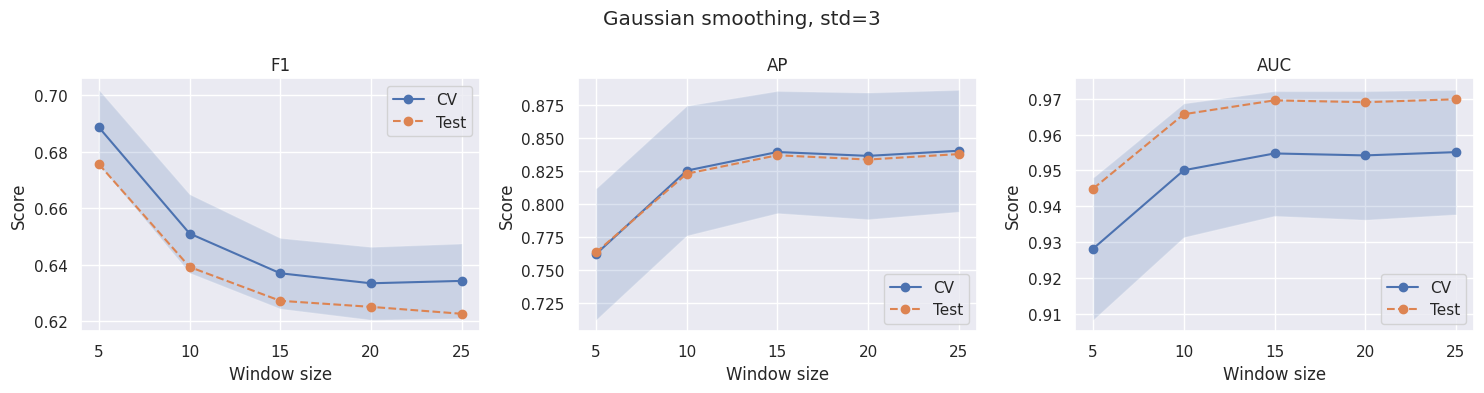

In [73]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing, std={std_val}", xlab="Window size")

In [18]:
std_val = 5

ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test = train_with_smoothing(
    smoothing_func=lambda probs, w: gaussian_moving_average(probs, window_size=w, std=std_val),
    smoothing_params_list=[5, 10, 15, 20, 25],
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer
)

Fold Average Precision: 0.6762, F1: 0.6666, AUC: 0.8902
Fold Average Precision: 0.8223, F1: 0.7030, AUC: 0.9369
Fold Average Precision: 0.7906, F1: 0.6759, AUC: 0.9367
Fold Average Precision: 0.7432, F1: 0.6871, AUC: 0.9294
Fold Average Precision: 0.7799, F1: 0.7062, AUC: 0.9477
Test Average Precision: 0.7631, F1: 0.6746, AUC: 0.9449
Fold Average Precision: 0.7394, F1: 0.6262, AUC: 0.9154
Fold Average Precision: 0.8804, F1: 0.6541, AUC: 0.9558
Fold Average Precision: 0.8571, F1: 0.6397, AUC: 0.9590
Fold Average Precision: 0.8126, F1: 0.6230, AUC: 0.9555
Fold Average Precision: 0.8545, F1: 0.6546, AUC: 0.9701
Test Average Precision: 0.8252, F1: 0.6346, AUC: 0.9662
Fold Average Precision: 0.7608, F1: 0.5854, AUC: 0.9254
Fold Average Precision: 0.8874, F1: 0.6161, AUC: 0.9592
Fold Average Precision: 0.8718, F1: 0.6137, AUC: 0.9640
Fold Average Precision: 0.8347, F1: 0.5745, AUC: 0.9636
Fold Average Precision: 0.8686, F1: 0.6159, AUC: 0.9751
Test Average Precision: 0.8398, F1: 0.5910, AUC:

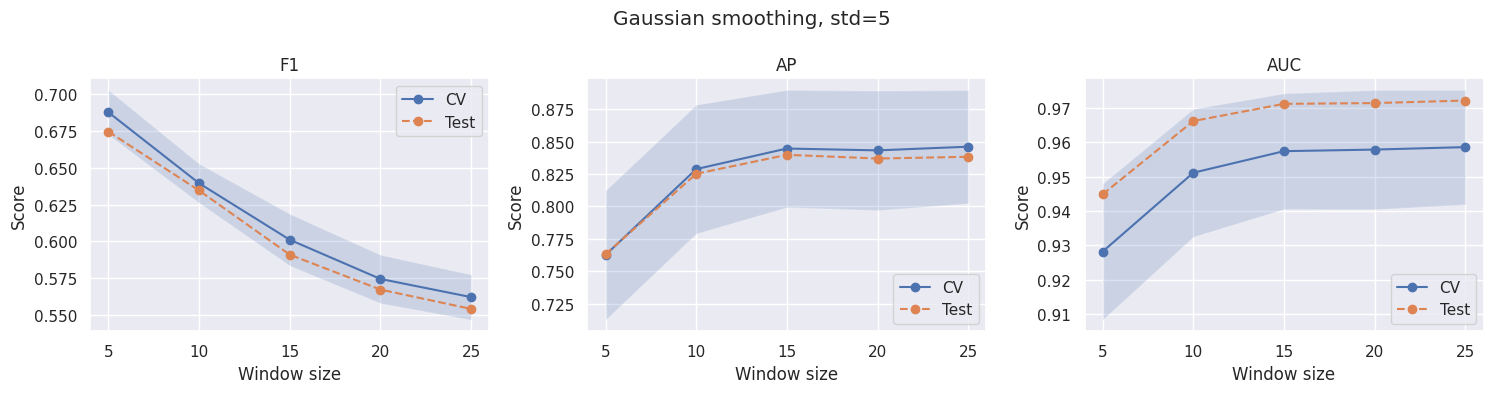

In [20]:
import seaborn as sns

plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing, std={std_val}", xlab="Window size")

In [ ]:
# tfidf
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [34]:
vectorizer =  build_vectorizer(name="tfidf", stop_words=final_stopwords_list, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,2),
                     max_df=0.95, min_df=2, preprocessor = prep)

In [35]:
std_val = 1

ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test = train_with_smoothing(
    smoothing_func=lambda probs, w: gaussian_moving_average(probs, window_size=w, std=std_val),
    smoothing_params_list=[5, 10, 15, 20, 25],
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    vectorizer=vectorizer
)

Fold Average Precision: 0.6318, F1: 0.5147, AUC: 0.8809
Fold Average Precision: 0.8079, F1: 0.5358, AUC: 0.9347
Fold Average Precision: 0.7807, F1: 0.5625, AUC: 0.9363
Fold Average Precision: 0.7228, F1: 0.5855, AUC: 0.9315
Fold Average Precision: 0.7551, F1: 0.5991, AUC: 0.9424
Test Average Precision: 0.7264, F1: 0.5895, AUC: 0.9372
Fold Average Precision: 0.6267, F1: 0.5199, AUC: 0.8791
Fold Average Precision: 0.8029, F1: 0.5332, AUC: 0.9329
Fold Average Precision: 0.7765, F1: 0.5623, AUC: 0.9337
Fold Average Precision: 0.7123, F1: 0.5799, AUC: 0.9290
Fold Average Precision: 0.7513, F1: 0.6007, AUC: 0.9409
Test Average Precision: 0.7197, F1: 0.5883, AUC: 0.9356
Fold Average Precision: 0.6344, F1: 0.5106, AUC: 0.8819
Fold Average Precision: 0.8103, F1: 0.5332, AUC: 0.9358
Fold Average Precision: 0.7835, F1: 0.5634, AUC: 0.9372
Fold Average Precision: 0.7258, F1: 0.5846, AUC: 0.9326
Fold Average Precision: 0.7580, F1: 0.5991, AUC: 0.9435
Test Average Precision: 0.7290, F1: 0.5882, AUC:

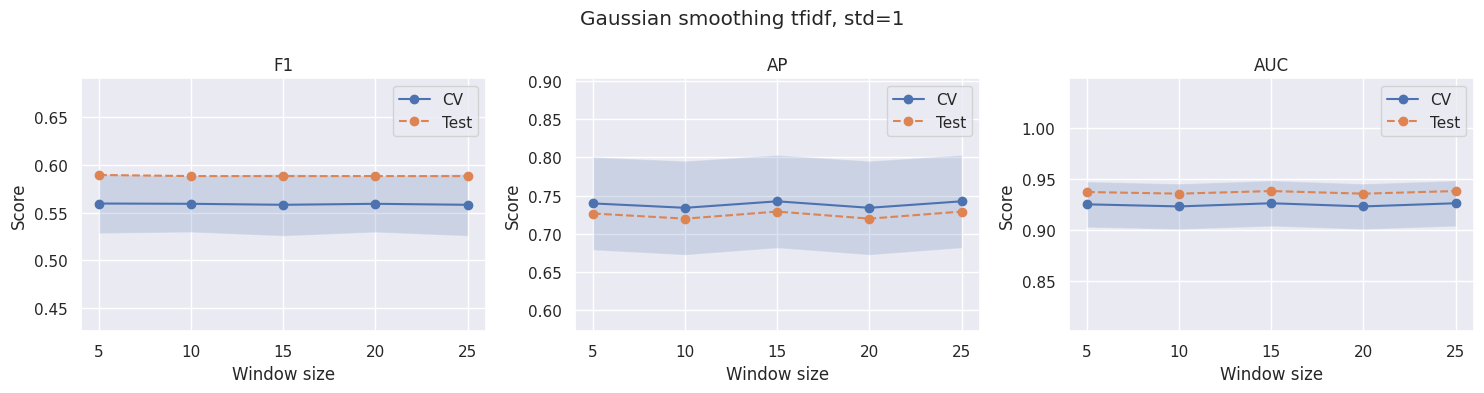

In [36]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing tfidf, std={std_val}", xlab="Window size", resize=True)

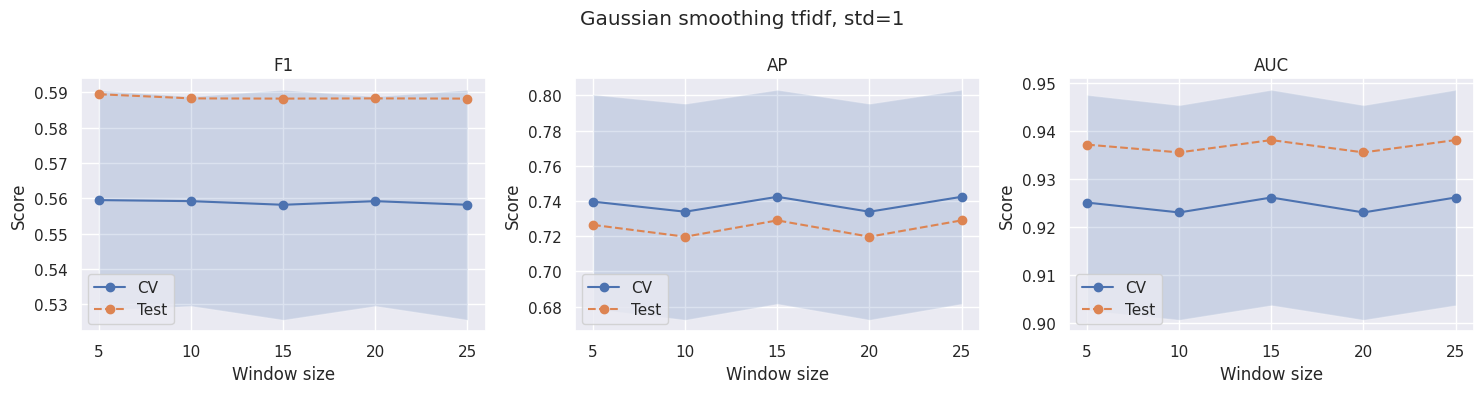

In [182]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing tfidf, std={std_val}", xlab="Window size")

In [ ]:
plot_cv_smooth(ap_lst, f1_lst, auc_lst, ap_test, f1_test, auc_test, alphas = [5, 10, 15, 20, 25], title=f"Gaussian smoothing tfidf, std={std_val}", xlab="Window size")